# Part II — Adaptive design of universal measurable estimators for ADAPT-VQE gradients

Implementation of the project description (hierarchy II-0 → II-E) with **PySCF + OpenFermion**.

This notebook is the sequel to the Part I notebook (`part1_gradient_measurement.ipynb`). Part I measured the oracle cost of three strategies (M1: FC-UG, M2: BAI-FC-IG, M3: BAI-FC-UG) on the nine Part I cases, and M3 came out cheapest in eight of nine. Part II keeps the M3 idea, BAI over shared fully commuting groups, and asks how much more can be saved by redesigning the measured operators themselves. Here the shots are simulated, not taken from an oracle. The II-0 level of this notebook is the finite-shot version of Part I's M3: the same parent groups and the same BAI elimination.

What is in this notebook

| Section | Content |
|---|---|
| 1 | Pauli algebra, fully-commuting (FC) contexts and their Clifford diagonalization circuits |
| 2 | The nine Part I benchmark cases: H₄ square (side 1.0 and 2.0 Å; HF and CISD), LiH at 3.0 Å (HF), H₂O at 0.9572 Å and 1.75 Å with angle 104.52° (HF and CISD; full 14 qubits, 140 generators); STO-3G, spin-orbital UCCSD pool, D_i = [H, G_i] |
| 3 | Estimator machinery: A = BC, coefficient splitting (II-A), ghost Paulis (II-B), dictionary (II-C), covariance models (prior / empirical / shrinkage), shot allocation |
| 4 | Best-arm identification with batchwise predictable redesign (II-D) and direct contrasts (II-E) |
| 5 | Phase 0 unit tests (a)–(e) |
| 6 | Phase 1–2 fixed-state benchmarks B1–B6 on the nine cases |
| 7 | Extra analyses: prior transfer and sensitivity to the prior weight ν |
| 8 | Phase 3 full logged BAI selection step, Phase 4 ADAPT trajectory with measured gradient selection (LiH) |

Conventions: generators are anti-Hermitian (G† = −G), so D_i = [H, G_i] is Hermitian and g_i = ⟨ψ|D_i|ψ⟩ = dE/dθ_i at θ = 0.
One *context-shot* = one state preparation + one measurement in one FC context. Exact state-vector quantities are used only for
validation files and for the runs explicitly labeled *oracle*.

In [1]:
import os
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[v] = "1"
import sys, json, time, copy, itertools
import numpy as np
import pandas as pd
from scipy import sparse
import openfermion as of
import pyscf
print("openfermion", of.__version__, "| pyscf", pyscf.__version__, "| numpy", np.__version__)

openfermion 1.8.1 | pyscf 2.14.0 | numpy 2.4.4


## 1. Pauli strings, FC grouping and Clifford diagonalization
Pauli strings are stored as (x, z) bit masks; qubit 0 is the most significant bit, the same ordering OpenFermion uses for state vectors.

In [2]:
import numpy as np

def popcount(a):
    return np.bitwise_count(np.asarray(a, dtype=np.uint64)).astype(np.int64)


def term_to_xz(term, nq):
    x = z = 0
    for q, p in term:
        bit = 1 << (nq - 1 - q)
        if p in "XY":
            x |= bit
        if p in "ZY":
            z |= bit
    return x, z


def xz_to_label(x, z, nq):
    s = []
    for q in range(nq):
        bit = 1 << (nq - 1 - q)
        s.append({(0, 0): "I", (1, 0): "X", (0, 1): "Z", (1, 1): "Y"}[(bool(x & bit), bool(z & bit))])
    return "".join(s)


def anticommutes(x1, z1, x2, z2):
    return (popcount((x1 & z2) ^ (z1 & x2)) & 1).astype(bool)


def group_fc(xs, zs, order):
    gid = -np.ones(len(xs), dtype=np.int64)
    mx, mz, mg = [], [], []
    ngroups = 0
    ax = np.zeros(len(xs), dtype=np.uint64); az = ax.copy(); ag = np.zeros(len(xs), dtype=np.int64)
    n = 0
    for l in order:
        if n:
            bad = anticommutes(ax[:n], az[:n], np.uint64(xs[l]), np.uint64(zs[l]))
            badg = np.bincount(ag[:n][bad], minlength=ngroups)
            ok = np.flatnonzero(badg == 0)
        else:
            ok = []
        g = ok[0] if len(ok) else ngroups
        if g == ngroups:
            ngroups += 1
        gid[l] = g
        ax[n] = xs[l]; az[n] = zs[l]; ag[n] = g; n += 1
    return gid, ngroups

A context's Paulis are reduced to independent generators over GF(2). Hadamards make the X block full rank, CNOTs clear it to the identity, S/CZ remove the Z block on the pivots, and final Hadamards turn everything into Z strings. The sign of each conjugated Pauli is tracked with the Aaronson–Gottesman rules, so a bitstring gives every Pauli eigenvalue in the context directly.

In [3]:
import numpy as np


def gf2_basis(xs, zs, nq):
    rows = []
    piv = []
    for x, z in zip(xs, zs):
        v = (int(x) << nq) | int(z)
        for p, r in zip(piv, rows):
            if v >> p & 1:
                v ^= r
        if v:
            p = v.bit_length() - 1
            for k in range(len(rows)):
                if rows[k] >> p & 1:
                    rows[k] ^= v
            rows.append(v); piv.append(p)
    X = np.array([[(r >> (nq + nq - 1 - q)) & 1 for q in range(nq)] for r in rows], dtype=np.uint8).reshape(-1, nq)
    Z = np.array([[(r >> (nq - 1 - q)) & 1 for q in range(nq)] for r in rows], dtype=np.uint8).reshape(-1, nq)
    return X, Z


def diagonalizing_circuit(xs, zs, nq):
    X, Z = gf2_basis(xs, zs, nq)
    k = X.shape[0]
    gates = []

    def h(q):
        gates.append(("H", q)); X[:, q], Z[:, q] = Z[:, q].copy(), X[:, q].copy()

    def s(q):
        gates.append(("S", q)); Z[:, q] ^= X[:, q]

    def cx(c, t):
        gates.append(("CX", c, t)); X[:, t] ^= X[:, c]; Z[:, c] ^= Z[:, t]

    def cz(a, b):
        gates.append(("CZ", a, b)); Z[:, a] ^= X[:, b]; Z[:, b] ^= X[:, a]

    def rref():
        pivots = []
        r = 0
        for q in range(nq):
            rows = np.flatnonzero(X[r:, q]) + r
            if len(rows) == 0:
                continue
            p = rows[0]
            if p != r:
                X[[r, p]] = X[[p, r]]; Z[[r, p]] = Z[[p, r]]
            for rr in np.flatnonzero(X[:, q]):
                if rr != r:
                    X[rr] ^= X[r]; Z[rr] ^= Z[r]
            pivots.append(q); r += 1
            if r == k:
                break
        return pivots

    while True:
        pivots = rref()
        if len(pivots) == k:
            break
        r = len(pivots)
        free = [q for q in range(nq) if Z[r, q] and q not in pivots]
        h(free[0])
    for r, p in enumerate(pivots):
        for q in np.flatnonzero(X[r]):
            if q != p:
                cx(p, q)
    for r, p in enumerate(pivots):
        if Z[r, p]:
            s(p)
    for a in range(k):
        for b in range(a + 1, k):
            if Z[a, pivots[b]]:
                cz(pivots[a], pivots[b])
    for p in pivots:
        h(p)
    assert not X.any()
    return gates


def conjugate(x, z, gates, nq):
    xb = np.array([(x >> (nq - 1 - q)) & 1 for q in range(nq)], dtype=np.uint8)
    zb = np.array([(z >> (nq - 1 - q)) & 1 for q in range(nq)], dtype=np.uint8)
    r = 0
    for g in gates:
        if g[0] == "H":
            q = g[1]; r ^= xb[q] & zb[q]; xb[q], zb[q] = zb[q], xb[q]
        elif g[0] == "S":
            q = g[1]; r ^= xb[q] & zb[q]; zb[q] ^= xb[q]
        elif g[0] == "CX":
            c, t = g[1], g[2]
            r ^= xb[c] & zb[t] & (xb[t] ^ zb[c] ^ 1)
            xb[t] ^= xb[c]; zb[c] ^= zb[t]
        elif g[0] == "CZ":
            a, b = g[1], g[2]
            for c, t, pre in ((a, b, True),):
                r ^= xb[t] & zb[t]; xb[t], zb[t] = zb[t], xb[t]
                r ^= xb[c] & zb[t] & (xb[t] ^ zb[c] ^ 1)
                xb[t] ^= xb[c]; zb[c] ^= zb[t]
                r ^= xb[t] & zb[t]; xb[t], zb[t] = zb[t], xb[t]
    assert not xb.any()
    zm = 0
    for q in range(nq):
        if zb[q]:
            zm |= 1 << (nq - 1 - q)
    return int(r), zm


def apply_gates(psi, gates, nq):
    psi = psi.reshape([2] * nq).copy()
    s2 = 1 / np.sqrt(2)
    for g in gates:
        if g[0] == "H":
            q = g[1]
            a = np.take(psi, 0, axis=q); b = np.take(psi, 1, axis=q)
            psi = np.stack([(a + b) * s2, (a - b) * s2], axis=q)
        elif g[0] == "S":
            q = g[1]
            idx = [slice(None)] * nq; idx[q] = 1
            psi[tuple(idx)] *= 1j
        elif g[0] == "CX":
            c, t = g[1], g[2]
            idx = [slice(None)] * nq; idx[c] = 1
            sub = psi[tuple(idx)]
            tt = t if t < c else t - 1
            psi[tuple(idx)] = np.flip(sub, axis=tt)
        elif g[0] == "CZ":
            a, b = g[1], g[2]
            idx = [slice(None)] * nq; idx[a] = 1; idx[b] = 1
            psi[tuple(idx)] *= -1
    return psi.reshape(-1)


def pauli_expect(psi, x, z):
    b = np.arange(len(psi), dtype=np.uint64)
    ny = int(popcount(np.uint64(x & z)))
    sgn = 1 - 2 * (popcount(b & np.uint64(z)) & 1)
    val = np.vdot(psi[b ^ np.uint64(x)], sgn * psi) * (1j) ** ny
    return val.real

## 2. Molecules, UCCSD pool, reference states, exact ADAPT

In [4]:
import numpy as np, itertools, time
from pyscf import gto, scf, ao2mo, fci, ci, mcscf
import openfermion as of
from openfermion.chem.molecular_data import spinorb_from_spatial
from openfermion.ops.representations import get_active_space_integrals


def build_molecule(atom, basis="sto-3g", n_frozen=0, charge=0, spin=0, symmetry=True):
    mol = gto.M(atom=atom, basis=basis, charge=charge, spin=spin, unit="Angstrom", symmetry=symmetry, verbose=0)
    mf = scf.RHF(mol)
    mf.conv_tol = 1e-10
    mf.kernel()
    if not mf.converged:
        mf = mf.newton().run()
    C = mf.mo_coeff
    h1 = C.T @ mf.get_hcore() @ C
    norb = C.shape[1]
    eri = ao2mo.restore(1, ao2mo.kernel(mol, C), norb)
    two = np.asarray(eri.transpose(0, 2, 3, 1), order="C")
    core = mol.energy_nuc()
    nelec = mol.nelectron
    if n_frozen:
        occ = list(range(n_frozen))
        act = list(range(n_frozen, norb))
        ecore, h1, two = get_active_space_integrals(h1, two, occ, act)
        core += ecore
        nelec -= 2 * n_frozen
    one_so, two_so = spinorb_from_spatial(h1, two)
    iop = of.InteractionOperator(core, one_so, 0.5 * two_so)
    fop = of.get_fermion_operator(iop)
    H = of.jordan_wigner(fop)
    H.compress(1e-10)
    nq = 2 * h1.shape[0]
    if n_frozen:
        cas = mcscf.CASCI(mf, nq // 2, nelec)
        efci = cas.kernel()[0]
    else:
        efci = fci.FCI(mf).kernel()[0]
    myci = ci.CISD(mf)
    if n_frozen:
        myci.frozen = n_frozen
    ecisd = myci.kernel()[0] + mf.e_tot
    return dict(H=H, nq=nq, nelec=nelec, e_hf=mf.e_tot, e_fci=efci, e_cisd=ecisd, mol=mol)


def uccsd_pool(nq, nelec):
    occ = list(range(nelec)); vir = list(range(nelec, nq))
    pool, labels = [], []
    for i in occ:
        for a in vir:
            if i % 2 == a % 2:
                op = of.FermionOperator(((a, 1), (i, 0))) - of.FermionOperator(((i, 1), (a, 0)))
                pool.append(op); labels.append(f"S {i}->{a}")
    for i, j in itertools.combinations(occ, 2):
        for a, b in itertools.combinations(vir, 2):
            if (i % 2 + j % 2) == (a % 2 + b % 2):
                if {i % 2, j % 2} != {a % 2, b % 2} and (i % 2 + j % 2) == 1:
                    continue
                op = of.FermionOperator(((b, 1), (a, 1), (j, 0), (i, 0)))
                op = op - of.hermitian_conjugated(op)
                pool.append(op); labels.append(f"D {i},{j}->{a},{b}")
    qpool = []
    for op in pool:
        q = of.jordan_wigner(op); q.compress(1e-12); qpool.append(q)
    return qpool, labels


def sector_basis(nq, nelec):
    idx = []
    for b in range(2 ** nq):
        occ = [q for q in range(nq) if b >> (nq - 1 - q) & 1]
        if len(occ) == nelec and sum(1 for q in occ if q % 2 == 0) == nelec // 2:
            idx.append(b)
    return np.array(idx)


def hf_state(nq, nelec):
    psi = np.zeros(2 ** nq, dtype=complex)
    psi[sum(1 << (nq - 1 - q) for q in range(nelec))] = 1
    return psi


def excitation_level(b, nq, nelec):
    occ = {q for q in range(nq) if b >> (nq - 1 - q) & 1}
    return len(occ - set(range(nelec)))


def cisd_state(Hs, nq, nelec, spin_penalty=1.0):
    basis = sector_basis(nq, nelec)
    sub = np.array([b for b in basis if excitation_level(b, nq, nelec) <= 2])
    S2 = of.get_sparse_operator(of.jordan_wigner(of.s_squared_operator(nq // 2)), nq).tocsr()
    Hsub = Hs[sub][:, sub].toarray()
    e, v = np.linalg.eigh(Hsub + spin_penalty * S2[sub][:, sub].toarray().real)
    psi = np.zeros(2 ** nq, dtype=complex)
    psi[sub] = v[:, 0]
    return np.vdot(psi, Hs @ psi).real, psi


def fci_sector(Hs, nq, nelec):
    basis = sector_basis(nq, nelec)
    e, v = np.linalg.eigh(Hs[basis][:, basis].toarray())
    return e[0]


def adapt_exact(Hs, gens_sparse, psi0, n_iter, tol=1e-8, e_target=None, select=None):
    from scipy.sparse.linalg import expm_multiply
    from scipy.optimize import minimize
    ops, thetas, hist = [], [], []

    def prep(th):
        psi = psi0
        for k, t in zip(ops, th):
            psi = expm_multiply(t * gens_sparse[k], psi)
        return psi

    def energy_grad(th):
        psi = prep(th)
        hpsi = Hs @ psi
        e = np.vdot(psi, hpsi).real
        g = np.zeros(len(th))
        lam = hpsi.copy(); phi = psi.copy()
        for k in reversed(range(len(th))):
            Gk = gens_sparse[ops[k]]
            g[k] = 2 * np.vdot(lam, Gk @ phi).real
            phi = expm_multiply(-th[k] * Gk, phi)
            lam = expm_multiply(-th[k] * Gk, lam)
        return e, g

    psi = psi0
    for it in range(n_iter):
        hpsi = Hs @ psi
        grads = np.array([2 * np.vdot(hpsi, G @ psi).real for G in gens_sparse])
        k = int(np.argmax(np.abs(grads))) if select is None else select(psi, grads, it)
        ops.append(k); thetas.append(0.0)
        res = minimize(energy_grad, np.array(thetas), jac=True, method="BFGS", options=dict(gtol=1e-8))
        thetas = list(res.x)
        psi = prep(res.x)
        hist.append(dict(op=k, energy=res.fun, maxgrad=np.max(np.abs(grads)), psi=psi.copy()))
        if e_target is not None and res.fun - e_target < tol:
            break
    return hist

## 3. Library, contexts, auxiliary (ghost) Paulis, state tables
`base_partition` is the non-overlapping FC grouping (sorted insertion). `extend_overlaps` lets important Paulis join extra compatible contexts (overlap for II-A). `build_aux` generates ghost candidates with bounded rules (Paulis of H not already required, products of pairs of heavy required Paulis in one context with weight ≤ w_max) and keeps only those compatible with at least two contexts; the rule of every kept auxiliary is logged.

`StateTables` rotates a state with each context's Clifford circuit and stores the outcome distribution and the ±1 eigenvalue table for all Paulis in the context.

In [5]:
import numpy as np, time


class Library:
    def __init__(self, nq, A, xs, zs):
        self.nq = nq
        self.A_req = A
        self.K, self.L_req = A.shape
        self.xs = np.array(xs, dtype=np.uint64)
        self.zs = np.array(zs, dtype=np.uint64)
        self.rule = ["req"] * self.L_req

    @property
    def L(self):
        return len(self.xs)

    @property
    def A(self):
        out = np.zeros((self.K, self.L))
        out[:, : self.L_req] = self.A_req
        return out

    def __deepcopy__(self, memo):
        new = Library.__new__(Library)
        new.nq, new.A_req, new.K, new.L_req = self.nq, self.A_req, self.K, self.L_req
        new.xs, new.zs, new.rule = self.xs.copy(), self.zs.copy(), list(self.rule)
        return new

    def add_aux(self, x, z, rule):
        self.xs = np.append(self.xs, np.uint64(x))
        self.zs = np.append(self.zs, np.uint64(z))
        self.rule.append(rule)
        return self.L - 1

    def label(self, l):
        return xz_to_label(int(self.xs[l]), int(self.zs[l]), self.nq)


class Contexts:
    def __init__(self, lib, members):
        self.lib = lib
        self.members = [np.array(m, dtype=np.int64) for m in members]
        self.build_circuits()

    def build_circuits(self):
        lib = self.lib
        self.gates, self.sign, self.zimg, self.n2q = [], [], [], []
        for mem in self.members:
            g = diagonalizing_circuit(lib.xs[mem], lib.zs[mem], lib.nq)
            rz = [conjugate(int(lib.xs[l]), int(lib.zs[l]), g, lib.nq) for l in mem]
            self.gates.append(g)
            self.sign.append(np.array([1 - 2 * r for r, _ in rz], dtype=np.int8))
            self.zimg.append(np.array([z for _, z in rz], dtype=np.uint64))
            self.n2q.append(sum(1 for q in g if q[0] in ("CX", "CZ")))
        self.n2q = np.array(self.n2q)

    def __len__(self):
        return len(self.members)

    def membership(self):
        cnt = np.zeros(self.lib.L, dtype=np.int64)
        for m in self.members:
            cnt[m] += 1
        return cnt


def base_partition(lib):
    w = np.linalg.norm(lib.A_req, axis=0)
    gid, ng = group_fc(lib.xs[: lib.L_req], lib.zs[: lib.L_req], np.argsort(-w))
    return [np.flatnonzero(gid == g) for g in range(ng)]


def compatible_contexts(lib, members, x, z):
    allm = np.concatenate(members)
    owner = np.concatenate([np.full(len(m), k) for k, m in enumerate(members)])
    bad = anticommutes(lib.xs[allm], lib.zs[allm], np.uint64(x), np.uint64(z))
    nbad = np.bincount(owner[bad], minlength=len(members))
    return np.flatnonzero(nbad == 0)


def extend_overlaps(lib, members, candidates, max_extra, rule_log=None):
    members = [list(m) for m in members]
    mx = [lib.xs[np.array(m)] for m in members]
    mz = [lib.zs[np.array(m)] for m in members]
    owner = np.concatenate([np.full(len(m), k) for k, m in enumerate(members)])
    allm = np.concatenate([np.array(m) for m in members])
    added = 0
    for l in candidates:
        x, z = lib.xs[l], lib.zs[l]
        bad = anticommutes(lib.xs[allm], lib.zs[allm], x, z)
        nbad = np.bincount(owner[bad], minlength=len(members))
        ok = [k for k in np.flatnonzero(nbad == 0) if l not in members[k]]
        for k in ok[:max_extra]:
            members[k].append(l)
            allm = np.append(allm, l); owner = np.append(owner, k)
            added += 1
    return [np.array(m) for m in members], added


def pair_product(x1, z1, x2, z2):
    return int(x1) ^ int(x2), int(z1) ^ int(z2)


def weight_of(x, z):
    return int(popcount(np.uint64(int(x) | int(z))))


def build_aux(lib, members, H_terms, top_per_ctx=8, max_weight=4, max_aux=1500, min_ctx=2):
    seen = {(int(x), int(z)) for x, z in zip(lib.xs, lib.zs)}
    cands = []
    for t in H_terms:
        if not t:
            continue
        x, z = term_to_xz(t, lib.nq)
        if (x, z) not in seen:
            cands.append((x, z, "aux:H"))
            seen.add((x, z))
    w = np.linalg.norm(lib.A_req, axis=0)
    for m in members:
        req = [l for l in m if l < lib.L_req]
        top = sorted(req, key=lambda l: -w[l])[:top_per_ctx]
        for a in range(len(top)):
            for b in range(a + 1, len(top)):
                x, z = pair_product(lib.xs[top[a]], lib.zs[top[a]], lib.xs[top[b]], lib.zs[top[b]])
                if (x, z) in seen or weight_of(x, z) > max_weight:
                    continue
                seen.add((x, z))
                cands.append((x, z, "aux:prod"))
    kept = []
    for x, z, rule in cands:
        n = len(compatible_contexts(lib, members, x, z))
        if n >= min_ctx:
            kept.append((n, weight_of(x, z), x, z, rule))
    kept.sort(key=lambda t: (-t[0], t[1]))
    kept = kept[:max_aux]
    idx = [lib.add_aux(x, z, rule) for _, _, x, z, rule in kept]
    return idx, len(cands)


class OutcomeRows:
    def __init__(self, support, sign, zimg):
        self.support, self.sign, self.zimg = support, sign, zimg
        self.shape = (len(support), len(zimg))

    def __getitem__(self, idx):
        om = self.support[idx]
        par = popcount(np.atleast_1d(om)[:, None] & self.zimg[None, :]) & 1
        out = (self.sign[None, :] * (1 - 2 * par)).astype(np.int8)
        return out if np.ndim(om) else out[0]

    def astype(self, dt):
        return self[np.arange(len(self.support))].astype(dt)

    def __len__(self):
        return len(self.support)


class StateTables:
    def __init__(self, ctx, psi, tol=1e-14):
        lib = ctx.lib
        self.support, self.p, self.E = [], [], []
        for k in range(len(ctx)):
            phi = apply_gates(psi, ctx.gates[k], lib.nq)
            pr = np.abs(phi) ** 2
            om = np.flatnonzero(pr > tol).astype(np.uint64)
            p = pr[om.astype(np.int64)]
            p /= p.sum()
            self.support.append(om); self.p.append(p)
            self.E.append(OutcomeRows(om, ctx.sign[k], ctx.zimg[k]))

    def mean(self, k):
        return self.p[k] @ self.E[k].astype(float)

    def cov(self, k):
        E = self.E[k].astype(float)
        mu = self.p[k] @ E
        return (E * self.p[k][:, None]).T @ E - np.outer(mu, mu)


def merge_contexts(lib, members, share, need, prune_share=0.5):
    members = [list(m) for m in members]
    alive = np.ones(len(members), bool)
    order = np.argsort(share)
    uniform = 1.0 / len(members)
    moved = 0
    for k in order:
        if share[k] >= prune_share * uniform:
            break
        cnt = np.zeros(lib.L, dtype=np.int64)
        for j in np.flatnonzero(alive):
            cnt[members[j]] += 1
        orphans = [l for l in members[k] if need[l] and cnt[l] == 1]
        others = [j for j in np.flatnonzero(alive) if j != k]
        allm = np.concatenate([np.array(members[j]) for j in others])
        owner = np.concatenate([np.full(len(members[j]), j) for j in others])
        plan, ok = {}, True
        extra = {}
        for l in orphans:
            bad = anticommutes(lib.xs[allm], lib.zs[allm], lib.xs[l], lib.zs[l])
            nbad = np.bincount(owner[bad], minlength=len(members))
            cand = [j for j in others if nbad[j] == 0 and
                    not any(anticommutes(lib.xs[e], lib.zs[e], lib.xs[l], lib.zs[l]) for e in extra.get(j, []))]
            if not cand:
                ok = False
                break
            j = max(cand, key=lambda j: share[j])
            plan[l] = j
            extra.setdefault(j, []).append(l)
        if ok:
            for l, j in plan.items():
                members[j].append(l)
            moved += len(plan)
            alive[k] = False
    return [np.array(m) for m, a in zip(members, alive) if a], int((~alive).sum()), moved

## 4. Covariance models and estimator design

For fixed contexts and shot fractions m_α, every linear unbiased estimator is a set of fragments X_α with Σ_α X_α E_αᵀ = A (this is A = BC with the fragments as universal operators).
`gls_design` finds the minimum-variance split: Paulis measured in only one active context keep their coefficient, Paulis measured in ≥2 contexts (required *or* auxiliary) are split with a Lagrange system on the shared coordinates only (Schur complement of each context's covariance). Shot fractions are then updated with m_α ∝ sqrt(tr W X_α Σ_α X_αᵀ) and the two steps alternate (coefficient splitting à la ICS, generalized to many gradients).

Because the split is the GLS/BLUE solution, it is the same for **every** linear objective (average variance or any pairwise contrast); only the shot allocation depends on the weight matrix W. This is used below: II-D/II-E change W, not the split formula.

`CovModel` = HF prior (+ ridge) shrunk toward the empirical covariance with λ = ν/(ν+m_α), plus a small permanent ridge in the design (failure mode 2).
`dictionary_design` (II-C) prunes low-share contexts whenever every required Pauli in them is still measured elsewhere, re-optimizes, and compresses each context block by SVD into the minimal set of universal operators.

In [6]:
import numpy as np, time


def weighted_cov(E, w):
    E = E.astype(float)
    tot = w.sum()
    mu = (w @ E) / tot
    return (E * w[:, None]).T @ E / tot - np.outer(mu, mu)


class CovModel:
    def __init__(self, ctx, prior_tables, ridge=0.05, nu=200.0, floor_ridge=0.01):
        self.ctx = ctx
        self.prior = prior_tables
        self.ridge = ridge
        self.floor_ridge = floor_ridge
        self.nu = nu
        n = len(ctx)
        self.data = {}
        self.nshots = np.zeros(n)
        self._prior_cov = [None] * n
        self._cache = {}

    def prior_cov(self, k):
        if self._prior_cov[k] is None:
            S = self.prior.cov(k)
            self._prior_cov[k] = S + self.ridge * np.eye(len(S))
        return self._prior_cov[k]

    def prior_raw(self, k):
        return self.prior_cov(k) - self.ridge * np.eye(len(self._prior_cov[k]))

    def ci_cov(self, k, nu):
        P = self.prior_raw(k)
        m = self.nshots[k]
        if m < 2:
            return P
        lam = nu / (nu + m)
        return lam * P + (1 - lam) * self.emp_cov(k)

    def attach(self, E_tables, counts):
        self.E_tables, self.counts = E_tables, counts

    def touch(self, k, n):
        self.nshots[k] += n
        self._cache.pop(k, None)
        self._cache.pop(("e", k), None)

    def lam(self, k):
        return 1.0 if self.nu == np.inf else self.nu / (self.nu + self.nshots[k])

    def emp_cov(self, k):
        if ("e", k) in self._cache:
            return self._cache[("e", k)]
        c = self.counts[k]
        nz = np.flatnonzero(c)
        m = c.sum()
        out = weighted_cov(self.E_tables[k][nz], c[nz].astype(float)) * m / (m - 1)
        self._cache[("e", k)] = out
        return out

    def cov(self, k):
        if k in self._cache:
            return self._cache[k]
        P = self.prior_cov(k)
        if self.nshots[k] < 2 or self.nu == np.inf:
            out = P
        else:
            lam = self.lam(k)
            out = lam * P + (1 - lam) * self.emp_cov(k) + self.floor_ridge * np.eye(len(P))
        self._cache[k] = out
        return out


class OracleCov:
    def __init__(self, tables, ridge=1e-6):
        self.t = tables; self.ridge = ridge; self.cache = {}

    def cov(self, k):
        if k not in self.cache:
            S = self.t.cov(k)
            self.cache[k] = S + self.ridge * np.eye(len(S))
        return self.cache[k]


def gls_design(ctx, covs, Ar, W=None, n_iter=10, floor=0.1, m0=None, split=True, active=None, tol=1e-12, fix_m=False):
    from scipy.linalg import cho_factor, cho_solve
    K = Ar.shape[0]
    if active is None:
        active = [k for k, mem in enumerate(ctx.members) if np.abs(Ar[:, mem]).max() > tol]
    active = list(active)
    nA = len(active)
    cnt = np.zeros(Ar.shape[1], dtype=np.int64)
    for k in active:
        cnt[ctx.members[k]] += 1
    shared = np.flatnonzero(cnt >= 2) if split else np.array([], dtype=np.int64)
    spos = -np.ones(Ar.shape[1], dtype=np.int64)
    spos[shared] = np.arange(len(shared))
    S = len(shared)
    Wm = np.eye(K) if W is None else W
    m = np.full(nA, 1.0 / nA) if m0 is None else np.asarray(m0, float) / np.sum(m0)
    loc, flat_idx, flat_val, owner = [], [], [], []
    for j, k in enumerate(active):
        mem = ctx.members[k]
        s = np.flatnonzero(spos[mem] >= 0)
        f = np.flatnonzero(spos[mem] < 0)
        Sig = covs.cov(k)
        if len(s):
            P = np.linalg.inv(Sig[np.ix_(s, s)])
            h = P @ (Sig[np.ix_(s, f)] @ Ar[:, mem[f]].T)
            ix = spos[mem[s]]
            flat_idx.append((ix[:, None] * S + ix[None, :]).ravel())
            flat_val.append(P.ravel()); owner.append(np.full(P.size, j))
        else:
            P, h = None, None
        loc.append((mem, s, f, Sig, P, h))
    if S:
        flat_idx = np.concatenate(flat_idx); flat_val = np.concatenate(flat_val); owner = np.concatenate(owner)
        rhs0 = Ar[:, shared].T.copy()
        for mem, s, f, Sig, P, h in loc:
            if len(s):
                rhs0[spos[mem[s]]] += h
    for it in range(n_iter):
        if S:
            G = np.bincount(flat_idx, weights=flat_val * m[owner], minlength=S * S).reshape(S, S)
            G[np.diag_indices(S)] += 1e-12
            nu = cho_solve(cho_factor(G), rhs0)
        Xs, cost = [], np.zeros(nA)
        for j, (mem, s, f, Sig, P, h) in enumerate(loc):
            X = np.zeros((K, len(mem)))
            X[:, f] = Ar[:, mem[f]]
            if len(s):
                X[:, s] = (m[j] * P @ nu[spos[mem[s]]] - h).T
            Xs.append(X)
            cost[j] = max(np.sum((Wm @ X @ Sig) * X), 1e-30)
        if fix_m:
            break
        new = np.sqrt(cost); new /= new.sum()
        new = np.maximum(new, floor / nA); new /= new.sum()
        done = np.max(np.abs(new - m)) < 1e-4 / nA
        m = new
        if done:
            break
    return dict(active=active, X=Xs, m=m, shared=shared, S=S, iters=it + 1)


def recon_residual(ctx, des, Ar):
    R = np.zeros_like(Ar)
    for k, X in zip(des["active"], des["X"]):
        R[:, ctx.members[k]] += X
    return np.abs(R - Ar).max()


def design_cov(des, covs, N=1.0):
    K = des["X"][0].shape[0]
    C = np.zeros((K, K))
    for k, X, mk in zip(des["active"], des["X"], des["m"]):
        C += X @ covs.cov(k) @ X.T / mk
    return C / N


def to_BC(ctx, des, L, rank_tol=1e-10, compress=True):
    from scipy import sparse
    blocks = []
    for k, X in zip(des["active"], des["X"]):
        mem = ctx.members[k]
        if not compress:
            keep = np.flatnonzero(np.abs(X).max(1) > 0)
            U = np.eye(X.shape[0])[:, keep]
            R = X[keep]
        else:
            U, s, Vt = np.linalg.svd(X, full_matrices=False)
            r = int(np.sum(s > rank_tol * s[0])) if s[0] > 0 else 0
            U = U[:, :r]
            R = s[:r, None] * Vt[:r]
        blocks.append((mem, U, R))
    Q = sum(R.shape[0] for _, _, R in blocks)
    nnz = sum(int(np.count_nonzero(R)) for _, _, R in blocks)
    ri = np.empty(nnz, dtype=np.int64); ci = np.empty(nnz, dtype=np.int64); vals = np.empty(nnz)
    B = np.zeros((des["X"][0].shape[0], Q))
    q = p = 0
    for mem, U, R in blocks:
        r, c = np.nonzero(R)
        m = len(r)
        ri[p:p + m] = r + q; ci[p:p + m] = mem[c]; vals[p:p + m] = R[r, c]
        B[:, q:q + R.shape[0]] = U
        q += R.shape[0]; p += m
    C = sparse.csr_matrix((vals, (ri, ci)), shape=(Q, L))
    return B, C


def cond_B(B):
    w = np.linalg.eigvalsh(B @ B.T)
    w = w[w > 1e-14 * w.max()]
    return float(np.sqrt(w.max() / w.min()))


def dictionary_design(ctx, covs, Ar, base_design, prune_share=0.25, rounds=3, n_iter=10):
    des = base_design
    active = list(des["active"])
    removed = []
    for _ in range(rounds):
        share = des["m"] * len(des["active"])
        cnt = np.zeros(Ar.shape[1], dtype=np.int64)
        for k in des["active"]:
            cnt[ctx.members[k]] += 1
        need = np.abs(Ar).max(0) > 1e-12
        order = np.argsort(share)
        drop = []
        for j in order:
            if share[j] >= prune_share:
                break
            k = des["active"][j]
            mem = ctx.members[k]
            crit = mem[need[mem]]
            if np.all(cnt[crit] >= 2):
                cnt[mem] -= 1
                drop.append(k)
        if not drop:
            break
        removed += drop
        active = [k for k in des["active"] if k not in set(drop)]
        des = gls_design(ctx, covs, Ar, n_iter=n_iter, active=active)
    Q_naive, Q = 0, 0
    svals = []
    for X in des["X"]:
        Q_naive += int(np.sum(np.abs(X).max(1) > 0))
        s = np.linalg.svd(X, compute_uv=False)
        r = int(np.sum(s > 1e-10 * max(s[0], 1e-300)))
        Q += r
        svals.append(s[:r])
    des = dict(des)
    des.update(removed=removed, Q=Q, Q_naive=Q_naive, rankA=int(np.linalg.matrix_rank(Ar)))
    return des

## 5. Best-arm identification

* Batches grow geometrically (×1.3). A context gets at least 2 shots in any batch where it is active.
* Fixed designs (II-0, II-A, II-B, II-C, oracle) pool all shots per context. Adaptive designs (II-D, II-E) are **batchwise predictable**: the design of batch t uses only data from batches < t, is frozen, and redesign happens when the cumulative shot count has doubled. Batch estimates are combined with weights fixed from the design-time predicted variance.
* Confidence radii: r_i = z·sd_i with a Bonferroni z over K gradients and the maximum number of rounds (δ = 0.05). Variances are plug-in estimates (empirical covariance, weakly shrunk to the classical prior with ν_CI = 20 shots).
* Individual rule (Eq. 38–39): eliminate i when U_i < max_j L_j. Contrast rule (II-E): once the leader's sign is resolved, eliminate j when the lower bound of |g_lead| − |g_j| = min_s (s_lead g_lead − s g_j) is positive.
* Stop when one candidate is left or when the leader is Δ-good with confidence (Δ = 1 mHa).

In [7]:
import numpy as np, time
from scipy.stats import norm


class Truth:
    def __init__(self, tables):
        self.t = tables

    def draw(self, k, n, rng):
        return rng.multinomial(n, self.t.p[k])


def int_alloc(b, m, minimum):
    raw = b * m
    n = np.floor(raw).astype(np.int64)
    rest = int(b - n.sum())
    if rest > 0:
        n[np.argsort(-(raw - n))[:rest]] += 1
    return np.maximum(n, minimum)


class Run:
    def __init__(self, ctx, A, truth, covmodel, prior_tables, cfg, rng, cache=None):
        self.cache = cache
        self.ctx, self.A, self.truth, self.cov, self.prior = ctx, A, truth, covmodel, prior_tables
        self.cfg, self.rng = cfg, rng
        self.K = A.shape[0]
        n = len(ctx)
        self.cum = [np.zeros(len(truth.t.p[k]), dtype=np.int64) for k in range(n)]
        self.segments = []
        if cfg["adaptive"]:
            covmodel.attach(truth.t.E, self.cum)
        self.log = []
        self.shots = 0
        self.design_time = 0.0
        self.n_designs = 0

    def proj_cov_cached(self, k, j, rows):
        Y, Cp = self.cache[j]
        nu = self.cfg.get("nu_ci", 20.0)
        c = self.cum[k]
        nz = np.flatnonzero(c)
        tot = c.sum()
        Cpr = Cp[np.ix_(rows, rows)]
        if tot < 2:
            return Cpr
        Ce = weighted_cov(Y[np.ix_(nz, rows)], c[nz].astype(float)) * tot / (tot - 1)
        lam = nu / (nu + tot)
        return lam * Cpr + (1 - lam) * Ce

    def proj_cov(self, k, Xrows):
        c = self.cum[k]
        nz = np.flatnonzero(c)
        tot = c.sum()
        Pk = self.cov.prior_raw(k)
        Cp = Xrows @ Pk @ Xrows.T
        if tot < 2:
            return Cp
        Z = self.truth.t.E[k][nz].astype(float) @ Xrows.T
        Ce = weighted_cov(Z, c[nz].astype(float)) * tot / (tot - 1)
        lam = self.cfg.get("nu_ci", 20.0) / (self.cfg.get("nu_ci", 20.0) + tot)
        return lam * Cp + (1 - lam) * Ce

    def seg_cov(self, seg, pos, rows):
        K = len(rows)
        C = np.zeros((K, K)); g = np.zeros(K)
        adaptive = self.cfg["adaptive"]
        used = []
        for j, (k, X, s, n) in enumerate(zip(seg["active"], seg["X"], seg["sums"], seg["n"])):
            if n == 0:
                continue
            Xr = X[pos]
            if not np.any(Xr):
                continue
            g += Xr @ (s / n)
            used.append((j, k, Xr, n))
        if not adaptive:
            lead = int(np.argmax(np.abs(g)))
            nu = self.cfg.get("nu_ci", 20.0)
            dg = np.zeros(K); col = np.zeros(K)
            for j, k, Xr, n in used:
                c = self.cum[k]
                nz = np.flatnonzero(c)
                tot = c.sum()
                if self.cache is not None:
                    Y, Cp = self.cache[j]
                    pd_ = Cp[pos, pos]; pc = Cp[pos, pos[lead]]
                    Z = Y[np.ix_(nz, pos)].astype(float) if tot >= 2 else None
                else:
                    P = self.cov.prior_raw(k)
                    XP = Xr @ P
                    pd_ = np.einsum("ij,ij->i", XP, Xr); pc = XP @ Xr[lead]
                    Z = self.truth.t.E[k][nz].astype(float) @ Xr.T if tot >= 2 else None
                if tot >= 2:
                    w = c[nz].astype(float)
                    D = Z - (w @ Z) / tot
                    ed = (w @ (D * D)) / (tot - 1)
                    ec = (w @ (D * D[:, [lead]])) / (tot - 1)
                    lam = nu / (nu + tot)
                    pd_ = lam * pd_ + (1 - lam) * ed
                    pc = lam * pc + (1 - lam) * ec
                dg += pd_ / n; col += pc / n
            C[np.diag_indices(K)] = dg
            C[:, lead] = col; C[lead, :] = col
            return g, C
        for j, k, Xr, n in used:
            if adaptive:
                C += Xr @ self.cov.ci_cov(k, self.cfg.get("nu_ci", 20.0)) @ Xr.T / n
            else:
                C += self.proj_cov(k, Xr) / n
        return g, C

    def estimate(self, rows):
        K = len(rows)
        gs, Cs, Ws = [], [], []
        for seg in self.segments:
            if self.cfg["adaptive"]:
                if "frozen" not in seg:
                    allrows = sorted(seg["rowpos_real"])
                    pos = [seg["rowpos"][r] for r in allrows]
                    seg["frozen"] = (allrows,) + self.seg_cov(seg, pos, allrows)
                allrows, gf, Cf = seg["frozen"]
                ix = [allrows.index(r) for r in rows]
                g, C = gf[ix], Cf[np.ix_(ix, ix)]
            else:
                pos = [seg["rowpos"][r] for r in rows]
                g, C = self.seg_cov(seg, pos, rows)
            w = np.sum(seg["n"]) / np.maximum(seg["pred_var"][np.array(rows)], 1e-300) if len(self.segments) > 1 else np.ones(K)
            gs.append(g); Cs.append(C); Ws.append(w)
        Wt = np.array(Ws); Wt /= Wt.sum(0)
        g = sum(w * x for w, x in zip(Wt, gs))
        C = sum(np.outer(w, w) * c for w, c in zip(Wt, Cs))
        return g, C

    def measure(self, seg, b):
        n = int_alloc(b, seg["m"], self.cfg.get("min_shots", 2))
        seg.setdefault("sums", [np.zeros(len(self.ctx.members[k])) for k in seg["active"]])
        seg.setdefault("n", np.zeros(len(seg["active"]), dtype=np.int64))
        for j, k in enumerate(seg["active"]):
            c = self.truth.draw(k, n[j], self.rng)
            self.cum[k] += c
            nz = np.flatnonzero(c)
            seg["sums"][j] += c[nz] @ self.truth.t.E[k][nz]
            seg["n"][j] += n[j]
            if self.cfg["adaptive"]:
                self.cov.touch(k, n[j])
        self.shots += int(n.sum())
        return n


def contrast_bounds(g, C, lead, j, s_lead, z):
    out = []
    for s in (1, -1):
        d = np.zeros(len(g)); d[lead] = s_lead; d[j] = -s
        v = max(d @ C @ d, 0.0)
        out.append((d @ g - z * np.sqrt(v), d @ g + z * np.sqrt(v)))
    return min(o[0] for o in out), max(-o[0] for o in out), out


def fixed_cache(des, truth_tables, covmodel, max_bytes=1.2e9):
    K = des["X"][0].shape[0]
    need = sum(len(truth_tables.p[k]) for k in des["active"]) * K * 4
    if need > max_bytes:
        return None
    out = []
    for k, X in zip(des["active"], des["X"]):
        Y = (truth_tables.E[k].astype(np.float32) @ X.T.astype(np.float32))
        out.append((Y, X @ covmodel.prior_raw(k) @ X.T))
    return out


def run_bai(ctx, A, truth, covmodel, prior_tables, cfg, rng, fixed_design=None, keep_log=False, cache=None):
    run = Run(ctx, A, truth, covmodel, prior_tables, cfg, rng, cache=cache)
    K = A.shape[0]
    rows = list(range(K))
    z = norm.ppf(1 - cfg["delta"] / (2 * K * cfg["max_rounds"]))
    Delta = cfg["Delta"]
    b = cfg["b0"]
    decided, selected, capped = False, None, False
    m_prev = None
    last = None
    W = None
    for r in range(cfg["max_rounds"]):
        t0 = time.time()
        Ar = A[rows]
        if fixed_design is not None:
            des = fixed_design
            if not run.segments:
                seg = dict(active=des["active"], X=des["X"], m=des["m"].copy(), rowpos={i: i for i in range(K)},
                           pred_var=np.ones(K))
                run.segments.append(seg)
            seg = run.segments[0]
            keep = np.array([np.abs(X[rows]).max() > 0 for X in seg["X"]])
            m = seg["m"] * keep
            seg_m = m / m.sum()
            seg["m"] = seg_m
        elif last is not None and run.shots < 2 * last["shots"]:
            prev = last["seg"]
            keep = np.array([np.abs(X[[prev["rowpos"][i] for i in rows]]).max() > 0 for X in prev["X"]])
            idx = np.flatnonzero(keep)
            mm = prev["m"][idx]; mm = mm / mm.sum()
            seg = dict(active=[prev["active"][j] for j in idx], X=[prev["X"][j] for j in idx], m=mm,
                       rowpos=prev["rowpos"], pred_var=prev["pred_var"], rowpos_real=list(rows))
            run.segments.append(seg)
        else:
            act = [k for k, mem in enumerate(ctx.members) if np.abs(Ar[:, mem]).max() > 1e-12]
            m0 = None
            if m_prev is not None:
                m0 = np.array([m_prev.get(k, np.nan) for k in act])
                m0[np.isnan(m0)] = np.nanmean(m0) if np.any(~np.isnan(m0)) else 1.0
            des = gls_design(ctx, run.cov, Ar, W=W, n_iter=cfg.get("n_iter", 3), active=act,
                             m0=m0, split=cfg.get("split", True), floor=cfg.get("floor", 0.1))
            Cpred = np.zeros((len(rows), len(rows)))
            for k, X, mk in zip(des["active"], des["X"], des["m"]):
                Cpred += X @ run.cov.cov(k) @ X.T / mk
            seg = dict(active=des["active"], X=des["X"], m=des["m"], rowpos={i: p for p, i in enumerate(rows)},
                       rowpos_real=list(rows))
            pv = np.full(K, np.inf); pv[rows] = np.diag(Cpred)
            seg["pred_var"] = pv
            run.segments.append(seg)
            m_prev = dict(zip(des["active"], des["m"]))
            last = dict(seg=seg, shots=max(run.shots, 1))
            run.n_designs += 1
        run.design_time += time.time() - t0
        run.measure(seg, b)
        g, C = run.estimate(rows)
        if cfg["adaptive"] and not keep_log:
            keep = last["seg"] if last is not None else None
            for old_seg in run.segments:
                if old_seg is not keep and "frozen" in old_seg and old_seg.get("X") is not None:
                    old_seg["X"] = None
                    old_seg["sums"] = None
        sd = np.sqrt(np.maximum(np.diag(C), 0))
        rad = z * sd
        Lb = np.maximum(0, np.abs(g) - rad); Ub = np.abs(g) + rad
        lead = int(np.argmax(np.abs(g)))
        s_lead = np.sign(g[lead]) if np.abs(g[lead]) > rad[lead] else 0
        elim = set()
        maxL = Lb.max()
        for p in range(len(rows)):
            if p != lead and Ub[p] < maxL:
                elim.add(p)
        hard = []
        if cfg["elim"] == "contrast" and s_lead != 0:
            for p in range(len(rows)):
                if p == lead or p in elim:
                    continue
                lo, hi, _ = contrast_bounds(g, C, lead, p, s_lead, z)
                if lo > 0:
                    elim.add(p)
        surv = [p for p in range(len(rows)) if p not in elim]
        if cfg["elim"] == "contrast" and s_lead != 0:
            worst = max([-contrast_bounds(g, C, lead, p, s_lead, z)[0] for p in surv if p != lead], default=-np.inf)
            good = worst <= Delta
        else:
            good = max([Ub[p] for p in surv if p != lead], default=-np.inf) - Lb[lead] <= Delta
        entry = dict(round=r, rows=[int(x) for x in rows], shots=run.shots, batch=int(b),
                     n_ctx=len(seg["active"]), lead=int(rows[lead]), eliminated=[int(rows[p]) for p in sorted(elim)],
                     design_time=time.time() - t0)
        if keep_log:
            entry.update(g=g.tolist(), rad=rad.tolist(), m=seg["m"].tolist(), active_ctx=[int(k) for k in seg["active"]])
        run.log.append(entry)
        if len(surv) == 1 or good:
            decided, selected = True, rows[lead]
            break
        rows = [rows[p] for p in surv]
        if cfg["adaptive"]:
            gg = g[surv]; ss = sd[surv]
            li = int(np.argmax(np.abs(gg)))
            gap = np.maximum(np.abs(gg[li]) - np.abs(gg), Delta)
            wj = 1.0 / gap ** 2
            wj[li] = 0
            wj /= max(wj.sum(), 1e-300)
            if cfg["objective"] == "contrast":
                sl = np.sign(gg[li]) or 1.0
                Wm = 1e-3 * np.eye(len(rows))
                for p in range(len(rows)):
                    if p == li:
                        continue
                    sp = np.sign(gg[p]) or 1.0
                    d = np.zeros(len(rows)); d[li] = sl; d[p] = -sp
                    Wm += wj[p] * np.outer(d, d)
                W = Wm
            else:
                wd = wj.copy(); wd[li] = 1.0
                W = np.diag(wd + 1e-3)
        if run.shots + b * cfg["growth"] > cfg["max_shots"]:
            capped = True
            selected = rows[int(np.argmax(np.abs(g[surv])))] if surv else rows[0]
            break
        b = int(b * cfg["growth"])
    if selected is None:
        selected = rows[0]
    extra = dict(segments=run.segments, cum=run.cum) if keep_log else {}
    return dict(**extra, selected=int(selected), shots=run.shots, rounds=len(run.log), decided=decided, capped=capped,
                design_time=run.design_time, n_designs=run.n_designs, log=run.log,
                ctx_used=len({k for s in run.segments for k, n in zip(s["active"], s["n"]) if n > 0}),
                n2q_per_shot=sum(int(n) * ctx.n2q[k] for s in run.segments for k, n in zip(s["active"], s["n"])) / max(run.shots, 1))

In [8]:
import numpy as np, copy, time
import openfermion as of


def prepare_system(name, atom, n_frozen=0, n_top=2000, max_extra=3, aux_top=12, aux_weight=6, max_aux=1000, aux_extra=4, symmetry=True):
    t0 = time.time()
    mol = build_molecule(atom, n_frozen=n_frozen, symmetry=symmetry)
    nq, ne = mol["nq"], mol["nelec"]
    pool, labels = uccsd_pool(nq, ne)
    Ds = []
    for G in pool:
        D = mol["H"] * G - G * mol["H"]
        D.compress(1e-10)
        Ds.append(D)
    terms = sorted(set().union(*[set(D.terms) for D in Ds]))
    pos = {t: i for i, t in enumerate(terms)}
    A = np.zeros((len(Ds), len(terms)))
    for i, D in enumerate(Ds):
        for t, c in D.terms.items():
            A[i, pos[t]] = c.real
    xz = np.array([term_to_xz(t, nq) for t in terms])
    lib0 = Library(nq, A, xz[:, 0], xz[:, 1])
    base = base_partition(lib0)
    w = np.linalg.norm(A, axis=0)
    libA = copy.deepcopy(lib0)
    memA, addedA = extend_overlaps(libA, base, np.argsort(-w)[:n_top], max_extra)
    libB = copy.deepcopy(libA)
    aux, ncand = build_aux(libB, memA, mol["H"].terms, top_per_ctx=aux_top, max_weight=aux_weight, max_aux=max_aux)
    memB, addedB = extend_overlaps(libB, memA, aux, aux_extra)
    sysd = dict(name=name, mol=mol, nq=nq, ne=ne, pool=pool, labels=labels, terms=terms, A=A,
                lib0=lib0, libA=libA, libB=libB, ctx0=Contexts(lib0, base), ctxA=Contexts(libA, memA),
                ctxB=Contexts(libB, memB), aux=aux, n_aux_candidates=ncand, addedA=addedA, addedB=addedB)
    sysd["Hs"] = of.get_sparse_operator(mol["H"], nq).tocsr()
    sysd["Gs"] = [of.get_sparse_operator(G, nq).tocsr() for G in pool]
    sysd["hf"] = hf_state(nq, ne)
    sysd["e_fci"] = fci_sector(sysd["Hs"], nq, ne)
    sysd["prep_time"] = time.time() - t0
    return sysd


def exact_gradients(sysd, psi):
    hp = sysd["Hs"] @ psi
    return np.array([2 * np.vdot(hp, G @ psi).real for G in sysd["Gs"]])

### Benchmark cases
The nine Part I cases and the reference values printed in the Part I report.

In [9]:
import numpy as np


def h4_square(a):
    return f"H 0 0 0; H {a} 0 0; H 0 {a} 0; H {a} {a} 0"


def water(r, angle=104.52):
    t = np.deg2rad(angle)
    return f"O 0 0 0; H {r} 0 0; H {r*np.cos(t):.6f} {r*np.sin(t):.6f} 0"


MOLECULES = {
    "LiH_3.0": dict(atom="Li 0 0 0; H 0 0 3.0", symmetry=True, label="LiH, R=3.0 A"),
    "H4_1.0": dict(atom=h4_square(1.0), symmetry=False, label="H4 square, side=1.0 A"),
    "H4_2.0": dict(atom=h4_square(2.0), symmetry=False, label="H4 square, side=2.0 A"),
    "H2O_eq": dict(atom=water(0.9572), symmetry=True, label="H2O eq., R(OH)=0.9572 A"),
    "H2O_1.75": dict(atom=water(1.75), symmetry=True, label="H2O stretch, R(OH)=1.75 A"),
}

CASES = [("LiH_3.0", "HF"), ("H4_1.0", "HF"), ("H4_1.0", "CISD"), ("H4_2.0", "HF"), ("H4_2.0", "CISD"),
         ("H2O_eq", "HF"), ("H2O_eq", "CISD"), ("H2O_1.75", "HF"), ("H2O_1.75", "CISD")]

PART_I_REFERENCE = {
    ("LiH_3.0", "HF"): dict(M1=2088380, M2=7368553, M3=1267508, contexts=980, terms=30196, g1=0.243187, g2=0.146799),
    ("H4_1.0", "HF"): dict(M1=182282619, M2=451756, M3=45857, contexts=356, terms=1276, g1=0.295316, g2=0.273776),
    ("H4_1.0", "CISD"): dict(M1=6066911, M2=53265, M3=9582, contexts=356, terms=1276, g1=0.142467, g2=0.024386),
    ("H4_2.0", "HF"): dict(M1=70335943, M2=112099, M3=9936, contexts=356, terms=1276, g1=0.315036, g2=0.298387),
    ("H4_2.0", "CISD"): dict(M1=7295352, M2=19188, M3=3441, contexts=356, terms=1276, g1=0.098961, g2=0.047102),
    ("H2O_eq", "HF"): dict(M1=None, M2=16545899, M3=None, contexts=9874, terms=81566, g1=0.304910, g2=0.203820),
    ("H2O_eq", "CISD"): dict(M1=None, M2=30149151647, M3=None, contexts=9874, terms=81566, g1=0.006925, g2=0.004861),
    ("H2O_1.75", "HF"): dict(M1=None, M2=9124527, M3=None, contexts=9874, terms=81566, g1=0.388493, g2=0.366638),
    ("H2O_1.75", "CISD"): dict(M1=None, M2=92693712, M3=None, contexts=9874, terms=81566, g1=0.106873, g2=0.089917),
}

## 6. Phase 0 — algebraic and statistical unit tests
(a) A = BC for every estimator, (b) auxiliary coefficients cancel, (c) analytic variance vs Monte Carlo (4000 repetitions), (d) II-B with an empty auxiliary set is exactly II-A, and — in the next cell — (e) a hand-solvable ghost example: target D = X₀ + Z₀, contexts {X₀, Z₁} and {Z₀, Z₁}, ghost Z₁ entering with +c and −c.

In [10]:
def lab2xz(s):
    n = len(s); x = z = 0
    for q, c in enumerate(s):
        b = 1 << (n - 1 - q)
        if c in "XY": x |= b
        if c in "ZY": z |= b
    return x, z


def rand_state(nq, seed):
    r = np.random.default_rng(seed)
    v = r.normal(size=2 ** nq) + 1j * r.normal(size=2 ** nq)
    return v / np.linalg.norm(v)


toy_labels = ["XXI", "ZII", "IZI", "ZZI", "XIZ", "YYI", "IIZ", "IXX", "ZIZ"]
toy_A = np.array([[0.5, 0.3, 0.2, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0],
                  [0.0, 0.0, 0.0, 0.4, -0.3, 0.1, 0.0, 0.2, 0.0],
                  [0.2, 0.0, 0.0, 0.6, 0.0, 0.0, 0.0, -0.4, 0.3]])
xz = np.array([lab2xz(s) for s in toy_labels])
toy0 = Library(3, toy_A, xz[:, 0], xz[:, 1])
tbase = base_partition(toy0)
toyA = copy.deepcopy(toy0)
tmemA, _ = extend_overlaps(toyA, tbase, range(toy0.L), 3)
toyB = copy.deepcopy(toyA)
taux, _ = build_aux(toyB, tmemA, [], top_per_ctx=6, max_weight=3, max_aux=10)
tmemB, _ = extend_overlaps(toyB, tmemA, taux, 3)
toy_empty = copy.deepcopy(toyA)
build_aux(toy_empty, tmemA, [], max_aux=0)
tctx = {"II-0": Contexts(toy0, tbase), "II-A": Contexts(toyA, tmemA), "II-B": Contexts(toyB, tmemB),
        "II-B, P_aux empty": Contexts(toy_empty, tmemA)}
tlib = {"II-0": toy0, "II-A": toyA, "II-B": toyB, "II-B, P_aux empty": toy_empty}
print("contexts II-0:", [[toy0.label(l) for l in m] for m in tbase])
print("contexts II-B:", [[toyB.label(l) + ("*" if l >= toyB.L_req else "") for l in m] for m in tmemB], " (* = auxiliary)")

psi_t = rand_state(3, 11)
rng = np.random.default_rng(0)
rows, designs_t = [], {}
for nm, c in tctx.items():
    L = tlib[nm]
    tab = StateTables(c, psi_t)
    orc = OracleCov(tab, ridge=0.0)
    des = gls_design(c, orc, L.A)
    designs_t[nm] = des
    B, C = to_BC(c, des, L.L)
    recon = (C.T @ B.T).T
    res = np.abs(recon - L.A).max()
    aux_res = np.abs(recon[:, L.L_req:]).max() if L.L > L.L_req else 0.0
    n = np.maximum(np.round(5000 * des["m"]).astype(int), 1)
    reps = []
    for _ in range(4000):
        reps.append(sum(X @ (rng.multinomial(nk, tab.p[k]) @ tab.E[k].astype(float) / nk) for k, X, nk in zip(des["active"], des["X"], n)))
    reps = np.array(reps)
    pred = sum(X @ orc.cov(k) @ X.T / nk for k, X, nk in zip(des["active"], des["X"], n))
    gt = np.array([sum(a * pauli_expect(psi_t, *lab2xz(toy_labels[l])) for l, a in enumerate(row)) for row in toy_A])
    rows.append({"design": nm, "|A-BC|": res, "aux net coeff": aux_res, "Q": B.shape[1],
                 "MC var / analytic (min)": (reps.var(0) / np.diag(pred)).min(),
                 "MC var / analytic (max)": (reps.var(0) / np.diag(pred)).max(),
                 "max |bias| / MC s.e.": np.max(np.abs(reps.mean(0) - gt) / np.sqrt(reps.var(0) / len(reps)))})
    assert res < 1e-10 and aux_res < 1e-10
same = max(np.abs(Xa - Xe).max() for Xa, Xe in zip(designs_t["II-A"]["X"], designs_t["II-B, P_aux empty"]["X"]))
print("(d) II-B with empty auxiliary set vs II-A, max coefficient difference:", same)
assert same < 1e-12
pd.DataFrame(rows)

contexts II-0: [['XXI', 'ZZI', 'YYI', 'IIZ'], ['ZII', 'IXX'], ['IZI', 'XIZ'], ['ZIZ']]
contexts II-B: [['XXI', 'ZZI', 'YYI', 'IIZ', 'ZZZ*'], ['ZII', 'IXX', 'IZZ*', 'ZZZ*'], ['IZI', 'XIZ', 'IIZ', 'IZZ*'], ['ZIZ', 'ZII', 'IZI', 'ZZI', 'IIZ', 'IZZ*', 'ZZZ*']]  (* = auxiliary)


(d) II-B with empty auxiliary set vs II-A, max coefficient difference: 0.0


,design,|A-BC|,aux net coeff,Q,MC var / analytic (min),MC var / analytic (max),max |bias| / MC s.e.
0,II-0,4.440892e-16,0.000000e+00,8,0.984535,1.008289,1.073016
1,II-A,6.185052e-13,0.000000e+00,11,1.011127,1.017830,1.577836
2,II-B,6.006307e-13,1.231913e-13,12,0.992478,1.010247,1.272157
3,"II-B, P_aux empty",6.185052e-13,0.000000e+00,11,0.969360,1.018683,0.778367


In [11]:
g_lib = Library(2, np.array([[1.0, 1.0]]), [lab2xz("XI")[0], lab2xz("ZI")[0]], [lab2xz("XI")[1], lab2xz("ZI")[1]])
q = g_lib.add_aux(*lab2xz("IZ"), "aux:hand")
g_ctx = Contexts(g_lib, [[0, q], [1, q]])
theta = np.array([0.9, 0.2, 0.35, 0.6])
psi_g = theta / np.linalg.norm(theta)
tab = StateTables(g_ctx, psi_g)
S1, S2 = tab.cov(0), tab.cov(1)
vX, vZ1, cXZ1 = S1[0, 0], S1[1, 1], S1[0, 1]
vZ, cZZ1 = S2[0, 0], S2[0, 1]
c_star = (cZZ1 - cXZ1) / (2 * vZ1)
V_ghost = (vX + c_star ** 2 * vZ1 + 2 * c_star * cXZ1) / 0.5 + (vZ + c_star ** 2 * vZ1 - 2 * c_star * cZZ1) / 0.5
V_plain = vX / 0.5 + vZ / 0.5
des = gls_design(g_ctx, OracleCov(tab, 0.0), g_lib.A, m0=[0.5, 0.5], fix_m=True, n_iter=1)
V_gls = design_cov(des, OracleCov(tab, 0.0))[0, 0]
print(f"hand-solved ghost coefficient c* = {c_star:.6f}, GLS gives {des['X'][0][0,1]:.6f} / {des['X'][1][0,1]:.6f}")
print(f"variance per shot: no ghost {V_plain:.6f}, closed form ghost {V_ghost:.6f}, GLS {V_gls:.6f}, "
      f"reduction {100*(1-V_gls/V_plain):.1f}%")
assert abs(V_gls - V_ghost) < 1e-10 and abs(des["X"][0][0, 1] - c_star) < 1e-10

hand-solved ghost coefficient c* = 0.365416, GLS gives 0.365416 / -0.365416
variance per shot: no ghost 2.995294, closed form ghost 2.546478, GLS 2.546478, reduction 15.0%


### Level II-C on a small system
The document asks to study the general dictionary problem first on small instances. Here the context library itself is part of the search: all maximal fully-commuting cliques of the 3-qubit library (9 required Paulis plus every weight ≤ 2 Pauli as a possible auxiliary). For each set of contexts the optimal dictionary and shot split are computed; the best 4-context cover is found exhaustively and then grown greedily. Oracle covariance — this is an upper-bound study of how much the extra freedom can give.

In [12]:
import networkx as nx
c_lib = copy.deepcopy(toy0)
for x in range(8):
    for z in range(8):
        if (x or z) and (x, z) not in {(int(a), int(b)) for a, b in zip(toy0.xs, toy0.zs)} and weight_of(x, z) <= 2:
            c_lib.add_aux(x, z, "aux:weight<=2")
graph = nx.Graph()
graph.add_nodes_from(range(c_lib.L))
for a in range(c_lib.L):
    for b in range(a + 1, c_lib.L):
        if not anticommutes(c_lib.xs[a], c_lib.zs[a], c_lib.xs[b], c_lib.zs[b]):
            graph.add_edge(a, b)
cliques = [sorted(c) for c in nx.find_cliques(graph) if any(l < c_lib.L_req for l in c)]


def eval_contexts(idx):
    ctx = Contexts(c_lib, [cliques[i] for i in idx])
    orc = OracleCov(StateTables(ctx, psi_t), 1e-9)
    d = gls_design(ctx, orc, c_lib.A, floor=0.0)
    B, C = to_BC(ctx, d, c_lib.L)
    return np.trace(design_cov(d, orc)), B.shape[1], int(ctx.n2q.sum())


t0 = time.time()
curve = {}
for combo in itertools.combinations(range(len(cliques)), 4):
    if set(range(c_lib.L_req)) <= set().union(*[cliques[i] for i in combo]):
        v = eval_contexts(combo)
        if 4 not in curve or v[0] < curve[4][0][0]:
            curve[4] = (v, combo)
chosen = list(curve[4][1])
for r in range(5, 9):
    trial = [(eval_contexts(chosen + [j]), j) for j in range(len(cliques)) if j not in chosen]
    v, j = min(trial, key=lambda t: t[0][0])
    chosen.append(j)
    curve[r] = (v, tuple(chosen))
ref = {nm: np.trace(design_cov(designs_t[nm], OracleCov(StateTables(tctx[nm], psi_t), 0.0))) for nm in ("II-0", "II-A", "II-B")}
rows_c = [dict(level=nm, contexts=len(tctx[nm]), total_var_per_shot=v) for nm, v in ref.items()]
rows_c += [dict(level=f"II-C (joint search)", contexts=r, total_var_per_shot=v[0], Q=v[1], two_qubit_gates=v[2],
                contexts_used=" | ".join(",".join(c_lib.label(l) for l in cliques[i]) for i in combo))
           for r, (v, combo) in sorted(curve.items())]
print(f"{len(cliques)} maximal FC cliques over {c_lib.L} Paulis ({c_lib.L - c_lib.L_req} auxiliaries of weight <= 2); "
      f"exhaustive search at 4 contexts, greedy growth after that; {time.time() - t0:.0f}s (oracle covariance, small-system study)")
pd.DataFrame(rows_c)

62 maximal FC cliques over 36 Paulis (27 auxiliaries of weight <= 2); exhaustive search at 4 contexts, greedy growth after that; 3s (oracle covariance, small-system study)


,level,contexts,total_var_per_shot,Q,two_qubit_gates,contexts_used
0,II-0,4,3.998139,NaN,NaN,NaN
1,II-A,4,2.605025,NaN,NaN,NaN
2,II-B,4,2.536753,NaN,NaN,NaN
3,II-C (joint search),4,2.210068,12.0,1.0,"XXI,ZZI,YYI,IIZ | XXI,XIZ,IIZ,IXI,IXZ,XII | XX..."
4,II-C (joint search),5,2.210067,13.0,1.0,"XXI,ZZI,YYI,IIZ | XXI,XIZ,IIZ,IXI,IXZ,XII | XX..."
5,II-C (joint search),6,2.210067,14.0,2.0,"XXI,ZZI,YYI,IIZ | XXI,XIZ,IIZ,IXI,IXZ,XII | XX..."
6,II-C (joint search),7,2.210069,18.0,3.0,"XXI,ZZI,YYI,IIZ | XXI,XIZ,IIZ,IXI,IXZ,XII | XX..."
7,II-C (joint search),8,2.210070,20.0,3.0,"XXI,ZZI,YYI,IIZ | XXI,XIZ,IIZ,IXI,IXZ,XII | XX..."


## 7. Systems, prior-based designs, reference states

In [13]:
import os, json, time, copy
import multiprocessing as mp
import numpy as np
import pandas as pd
from scipy import sparse

QUICK = os.environ.get("QUICK", "0") == "1"
N_SEEDS = 3 if QUICK else 50
N_SEEDS_ADAPTIVE = 2 if QUICK else 20
N_SEEDS_LARGE = 2 if QUICK else 10
N_SEEDS_LARGE_ADAPTIVE = 2 if QUICK else 5
N_TRAJ = 2 if QUICK else 4
N_WORKERS = 2
OUT = "results"
os.makedirs(OUT, exist_ok=True)
os.makedirs(f"{OUT}/validation", exist_ok=True)

CFG = dict(delta=0.05, Delta=1e-3, b0=None, growth=1.3, max_rounds=70, max_shots=1e12, nu_ci=20.0,
           adaptive=False, elim="individual", objective="pairs", min_shots=2, n_iter=3, floor=0.1)

METHODS = {
    "B1 II-0": dict(ctx="ctx0", lib="lib0", kind="fixed", design="II-0"),
    "B2 II-A": dict(ctx="ctxA", lib="libA", kind="fixed", design="II-A"),
    "B3 II-B": dict(ctx="ctxB", lib="libB", kind="fixed", design="II-B"),
    "B4 II-C": dict(ctx="ctxB", lib="libB", kind="fixed", design="II-C"),
    "B5 II-D": dict(ctx="ctxB", lib="libB", kind="adaptive", objective="pairs", elim="individual"),
    "B6 II-E": dict(ctx="ctxB", lib="libB", kind="adaptive", objective="contrast", elim="contrast"),
    "oracle II-B": dict(ctx="ctxB", lib="libB", kind="fixed", design="oracle"),
}

Build the five molecules exactly as in Part I (H₄ without point-group symmetry, H₂O at 104.52°, no frozen core). The pool is the Nₑ/S_z-conserving spin-orbital UCCSD pool: K = 26 for H₄, 92 for LiH and 140 for H₂O. For H₂O the ghost candidates come from the 6 heaviest Paulis of each context instead of 12, to keep the candidate list within reach.

In [14]:
SYSTEMS = {k: dict(atom=v["atom"], symmetry=v["symmetry"], aux_top=6 if k.startswith("H2O") else 12)
           for k, v in MOLECULES.items()}
systems = {}
for name, spec in SYSTEMS.items():
    s = prepare_system(name, spec["atom"], symmetry=spec["symmetry"], aux_top=spec["aux_top"])
    systems[name] = s
    m = s["mol"]
    print(f"{name}: {s['nq']} qubits, {s['ne']} electrons, H terms {len(m['H'].terms)}, pool K={len(s['pool'])}")
    print(f"   E_HF={m['e_hf']:.6f}  E_CISD={m['e_cisd']:.6f}  E_FCI={m['e_fci']:.6f} (sector FCI {s['e_fci']:.6f})")
    print(f"   L_req={s['A'].shape[1]}, rank(A)={np.linalg.matrix_rank(s['A'])}, FC contexts={len(s['ctx0'])}, "
          f"extra memberships II-A={s['addedA']}, aux kept={len(s['aux'])} of {s['n_aux_candidates']} candidates, "
          f"extra memberships II-B={s['addedB']}, prep {s['prep_time']:.0f}s")
    psi_r = np.random.default_rng(1).normal(size=2 ** s["nq"]) + 0j
    psi_r /= np.linalg.norm(psi_r)
    tab = StateTables(s["ctxB"], psi_r)
    err = max(abs(tab.mean(k)[j] - pauli_expect(psi_r, int(s["libB"].xs[l]), int(s["libB"].zs[l])))
              for k, mem in enumerate(s["ctxB"].members) for j, l in list(enumerate(mem))[:3])
    print(f"   Clifford diagonalization check on a random state, all {len(s['ctxB'])} II-B contexts: max error {err:.1e}")
    assert err < 1e-10

LiH_3.0: 12 qubits, 4 electrons, H terms 631, pool K=92
   E_HF=-7.710830  E_CISD=-7.798753  E_FCI=-7.798843 (sector FCI -7.798843)
   L_req=30196, rank(A)=92, FC contexts=956, extra memberships II-A=4764, aux kept=1000 of 6272 candidates, extra memberships II-B=4000, prep 37s


   Clifford diagonalization check on a random state, all 956 II-B contexts: max error 1.0e-14


H4_1.0: 8 qubits, 4 electrons, H terms 93, pool K=26
   E_HF=-1.761075  E_CISD=-1.910469  E_FCI=-1.915107 (sector FCI -1.915107)
   L_req=1276, rank(A)=26, FC contexts=37, extra memberships II-A=414, aux kept=277 of 415 candidates, extra memberships II-B=812, prep 1s
   Clifford diagonalization check on a random state, all 37 II-B contexts: max error 1.9e-16


H4_2.0: 8 qubits, 4 electrons, H terms 93, pool K=26
   E_HF=-1.541255  E_CISD=-1.873725  E_FCI=-1.897849 (sector FCI -1.897849)
   L_req=1276, rank(A)=26, FC contexts=33, extra memberships II-A=356, aux kept=347 of 409 candidates, extra memberships II-B=1020, prep 1s
   Clifford diagonalization check on a random state, all 33 II-B contexts: max error 2.4e-16


H2O_eq: 14 qubits, 10 electrons, H terms 1126, pool K=140
   E_HF=-74.962928  E_CISD=-75.011701  E_FCI=-75.012404 (sector FCI -75.012404)
   L_req=81634, rank(A)=140, FC contexts=2409, extra memberships II-A=5522, aux kept=1000 of 2609 candidates, extra memberships II-B=3998, prep 110s


   Clifford diagonalization check on a random state, all 2409 II-B contexts: max error 1.4e-14


H2O_1.75: 14 qubits, 10 electrons, H terms 1118, pool K=140
   E_HF=-74.541459  E_CISD=-74.764323  E_FCI=-74.800924 (sector FCI -74.800924)
   L_req=81594, rank(A)=140, FC contexts=2431, extra memberships II-A=5595, aux kept=1000 of 2829 candidates, extra memberships II-B=4000, prep 112s


   Clifford diagonalization check on a random state, all 2431 II-B contexts: max error 1.6e-14


Save Hamiltonian, generator labels, A matrix, Pauli libraries with generation rules and every context with its Clifford circuit (required outputs i–iii).

In [15]:
def save_system(s):
    nm = s["name"]
    lib = s["libB"]
    ham = {str(k): [float(np.real(v)), float(np.imag(v))] for k, v in s["mol"]["H"].terms.items()}
    json.dump(dict(hamiltonian=ham, generators=s["labels"], n_qubits=s["nq"], n_electrons=s["ne"]),
              open(f"{OUT}/{nm}_hamiltonian_generators.json", "w"))
    np.savez_compressed(f"{OUT}/{nm}_A_matrix.npz", A=s["A"], paulis=np.array([s["lib0"].label(l) for l in range(s["lib0"].L)]))
    json.dump(dict(required=[lib.label(l) for l in range(lib.L_req)],
                   auxiliary=[dict(pauli=lib.label(l), rule=lib.rule[l]) for l in s["aux"]]),
              open(f"{OUT}/{nm}_pauli_libraries.json", "w"))
    for key in ("ctx0", "ctxA", "ctxB"):
        c = s[key]
        L = c.lib
        json.dump([dict(paulis=[L.label(l) for l in mem], clifford=[list(g) for g in c.gates[k]], n_2q=int(c.n2q[k]),
                        z_images=[int(z) for z in c.zimg[k]], signs=[int(x) for x in c.sign[k]])
                   for k, mem in enumerate(c.members)], open(f"{OUT}/{nm}_{key}_contexts.json", "w"), default=int)

for s in systems.values():
    save_system(s)

Prior-based designs (classical prior = HF state). Every design is checked for ‖A − BC‖ < 1e-8 and written to disk (outputs iv–v).

In [16]:
def make_designs(s):
    hf = s["hf"]
    out = {}
    s["prior"] = {k: StateTables(s[k], hf) for k in ("ctx0", "ctxA", "ctxB")}
    s["covprior"] = {k: CovModel(s[k], s["prior"][k]) for k in ("ctx0", "ctxA", "ctxB")}
    for nm, ck, lk in (("II-0", "ctx0", "lib0"), ("II-A", "ctxA", "libA"), ("II-B", "ctxB", "libB")):
        t = time.time()
        d = gls_design(s[ck], s["covprior"][ck], s[lk].A)
        d["time"] = time.time() - t
        out[nm] = d
    t = time.time()
    d = dictionary_design(s["ctxB"], s["covprior"]["ctxB"], s["libB"].A, out["II-B"])
    d["time"] = time.time() - t + out["II-B"]["time"]
    out["II-C"] = d
    for nm, d in out.items():
        lk = METHODS[[m for m in METHODS if METHODS[m].get("design") == nm][0]]["lib"]
        ck = METHODS[[m for m in METHODS if METHODS[m].get("design") == nm][0]]["ctx"]
        res = recon_residual(s[ck], d, s[lk].A)
        assert res < 1e-8, (nm, res)
        d["residual"] = res
        B, C = to_BC(s[ck], d, s[lk].L, compress=(nm == "II-C"))
        d["Q"] = B.shape[1]
        d["residual_BC"] = float(np.abs(C.T @ B.T - s[lk].A.T).max())
        assert d["residual_BC"] < 1e-8
        d["cond_B"] = cond_B(B)
        sparse.save_npz(f"{OUT}/{s['name']}_design_{nm}_C.npz", C)
        np.savez_compressed(f"{OUT}/{s['name']}_design_{nm}_B.npz", B=B, m=d["m"], active=np.array(d["active"]))
        del B, C
    s["designs"] = out
    return out

design_rows = []
for s in systems.values():
    ds = make_designs(s)
    for nm, d in ds.items():
        ck = {"II-0": "ctx0", "II-A": "ctxA"}.get(nm, "ctxB")
        n2q = np.array([s[ck].n2q[k] for k in d["active"]])
        design_rows.append(dict(system=s["name"], level=nm, contexts=len(d["active"]), removed_contexts=len(d.get("removed", [])), shared_coords=d["S"],
                                Q=d["Q"], rankA=int(np.linalg.matrix_rank(s["A"])), cond_B=round(d["cond_B"], 1),
                                max_residual=d["residual"], mean_2q_gates=round(float(n2q.mean()), 1),
                                shot_weighted_2q=round(float(n2q @ d["m"]), 1), design_s=round(d["time"], 1)))
pd.DataFrame(design_rows)

,system,level,contexts,removed_contexts,shared_coords,Q,rankA,cond_B,max_residual,mean_2q_gates,shot_weighted_2q,design_s
0,LiH_3.0,II-0,956,0,0,38997,92,2.6,0.000000e+00,24.6,14.0,0.2
1,LiH_3.0,II-A,956,0,1906,83686,92,1.0,9.111345e-11,25.0,20.3,2.1
2,LiH_3.0,II-B,956,0,2906,85102,92,1.0,8.937806e-11,25.0,20.4,4.3
3,LiH_3.0,II-C,956,0,2906,27306,92,2.0,8.937806e-11,25.0,20.4,4.7
4,H4_1.0,II-0,37,0,0,337,26,1.4,0.000000e+00,7.2,7.0,0.0
5,H4_1.0,II-A,37,0,316,462,26,1.6,9.286960e-12,7.2,7.3,0.0
6,H4_1.0,II-B,37,0,581,533,26,1.8,8.653134e-12,7.2,7.4,0.1
7,H4_1.0,II-C,37,0,581,420,26,2.0,8.653134e-12,7.2,7.4,0.1
8,H4_2.0,II-0,33,0,0,279,26,2.1,0.000000e+00,6.2,5.6,0.0
9,H4_2.0,II-A,33,0,236,377,26,2.0,3.338468e-12,6.2,5.5,0.0


States: HF (ADAPT iteration 0) and CISD (singlet, exact diagonalization in the HF+S+D space). For LiH the exact-ADAPT state after 3 operators is also built, for Phase 3.

In [17]:
def build_states(s, with_adapt=False, n_adapt_snapshot=3):
    states = {"HF": s["hf"]}
    e, psi = cisd_state(s["Hs"], s["nq"], s["ne"])
    states["CISD"] = psi
    s["states"] = states
    s["energies"] = {k: float(np.vdot(v, s["Hs"] @ v).real) for k, v in states.items()}
    if not with_adapt:
        return states
    hist = adapt_exact(s["Hs"], s["Gs"], s["hf"], 30, e_target=s["e_fci"], tol=1.6e-3)
    s["adapt_exact"] = [dict(op=s["labels"][h["op"]], dE=h["energy"] - s["e_fci"], maxgrad=h["maxgrad"]) for h in hist]
    states[f"ADAPT-{n_adapt_snapshot}"] = hist[n_adapt_snapshot - 1]["psi"]
    s["states"] = states
    s["energies"] = {k: float(np.vdot(v, s["Hs"] @ v).real) for k, v in states.items()}
    return states

for s in systems.values():
    build_states(s, with_adapt=(s["name"] == "LiH_3.0"))
    print(s["name"], {k: round(v - s["e_fci"], 5) for k, v in s["energies"].items()})
    if "adapt_exact" in s:
        print("   exact ADAPT:", [(h["op"], f"{h['dE']:.2e}") for h in s["adapt_exact"]])

LiH_3.0 {'HF': np.float64(0.08801), 'CISD': np.float64(9e-05), 'ADAPT-3': np.float64(0.0234)}
   exact ADAPT: [('D 2,3->10,11', '5.46e-02'), ('D 2,3->4,11', '3.61e-02'), ('D 2,3->5,10', '2.34e-02'), ('D 2,3->4,5', '5.79e-03'), ('S 3->5', '3.18e-03'), ('S 2->10', '6.84e-04')]
H4_1.0 {'HF': np.float64(0.15403), 'CISD': np.float64(0.00464)}
H4_2.0 {'HF': np.float64(0.35659), 'CISD': np.float64(0.02412)}


H2O_eq {'HF': np.float64(0.04948), 'CISD': np.float64(0.0007)}


H2O_1.75 {'HF': np.float64(0.25946), 'CISD': np.float64(0.0366)}


Oracle-only analytic comparison: true variance of each prior-designed estimator, relative to II-0 (total gradient variance and the variance of the top-two contrast).

In [18]:
def state_setup(s, st):
    psi = s["states"][st]
    truth = {k: StateTables(s[k], psi) for k in ("ctx0", "ctxA", "ctxB")}
    g = exact_gradients(s, psi)
    oracle = {k: OracleCov(truth[k]) for k in truth}
    for nm, d in s["designs"].items():
        ck = {"II-0": "ctx0", "II-A": "ctxA"}.get(nm, "ctxB")
        gd = sum(X @ truth[ck].mean(k) for k, X in zip(d["active"], d["X"]))
        assert np.abs(gd - g).max() < 1e-8
    t = time.time()
    od = gls_design(s["ctxB"], oracle["ctxB"], s["libB"].A)
    od["time"] = time.time() - t
    return dict(truth=truth, g=g, oracle=oracle, oracle_design=od)


def analytic_table(s, st, setup):
    g = setup["g"]
    order = np.argsort(-np.abs(g))
    i, j = order[0], order[1]
    d = np.zeros(len(g)); d[i] = np.sign(g[i]); d[j] = -np.sign(g[j])
    rows = []
    items = list(s["designs"].items()) + [("oracle II-B", setup["oracle_design"])]
    for nm, des in items:
        ck = {"II-0": "ctx0", "II-A": "ctxA"}.get(nm, "ctxB")
        C = design_cov(des, setup["oracle"][ck])
        rows.append(dict(system=s["name"], state=st, design=nm, total_var=np.trace(C), top_contrast_var=d @ C @ d))
    df = pd.DataFrame(rows)
    df["total_var_vs_II0"] = df.total_var / df.total_var.iloc[0]
    df["contrast_var_vs_II0"] = df.top_contrast_var / df.top_contrast_var.iloc[0]
    return df

Workers for the finite-shot benchmark (fork-based pool, 2 processes).

In [19]:
G = {}


def one_run(args):
    method, seed = args
    s, setup, spec = G["s"], G["setup"], METHODS[method]
    ck, lk = spec["ctx"], spec["lib"]
    cfg = dict(CFG, b0=20 * len(s[ck]))
    rng = np.random.default_rng(1000 + seed)
    truth = Truth(setup["truth"][ck])
    if spec["kind"] == "fixed":
        des = setup["oracle_design"] if spec["design"] == "oracle" else s["designs"][spec["design"]]
        out = run_bai(s[ck], s[lk].A, truth, G["covmodel"], s["prior"][ck], cfg, rng, fixed_design=des, cache=G["cache"])
        out["design_time"] += des["time"]
    else:
        cfg.update(adaptive=True, objective=spec["objective"], elim=spec["elim"])
        cm = CovModel(s[ck], s["prior"][ck], nu=G.get("nu", 200.0))
        cm._prior_cov = G["covmodel"]._prior_cov
        out = run_bai(s[ck], s[lk].A, truth, cm, s["prior"][ck], cfg, rng)
    g = np.abs(setup["g"])
    out["exact_best"] = bool(g[out["selected"]] >= g.max() - 1e-9)
    out["delta_good"] = bool(g[out["selected"]] >= g.max() - CFG["Delta"])
    out.pop("log")
    return out


def run_method(s, st, setup, method, n_seeds):
    spec = METHODS[method]
    ck = spec["ctx"]
    cm = s["covprior"][ck]
    for k in range(len(s[ck])):
        cm.prior_cov(k)
    cache = None
    if spec["kind"] == "fixed":
        des = setup["oracle_design"] if spec["design"] == "oracle" else s["designs"][spec["design"]]
        cache = fixed_cache(des, setup["truth"][ck], cm)
    G.update(s=s, setup=setup, covmodel=cm, cache=cache)
    workers = 1 if (s["nq"] >= 14 and spec["kind"] != "fixed") else N_WORKERS
    with mp.get_context("fork").Pool(workers) as pool:
        res = list(pool.imap(one_run, [(method, k) for k in range(n_seeds)], chunksize=1))
    G["cache"] = None
    return res


def summarize(res):
    shots = np.array([r["shots"] for r in res], float)
    return dict(P_best=np.mean([r["exact_best"] for r in res]), P_delta_good=np.mean([r["delta_good"] for r in res]),
                N50=np.median(shots), N25=np.percentile(shots, 25), N75=np.percentile(shots, 75), N90=np.percentile(shots, 90),
                failures=int(sum(not r["delta_good"] for r in res)), capped=int(sum(r["capped"] for r in res)),
                rounds=np.median([r["rounds"] for r in res]), design_s=np.mean([r["design_time"] for r in res]),
                redesigns=np.mean([r.get("n_designs", 0) for r in res]), contexts_used=np.median([r["ctx_used"] for r in res]),
                twoq_per_shot=np.mean([r["n2q_per_shot"] for r in res]))

## 8. Phase 1–2 fixed-state benchmarks
B1 II-0, B2 II-A, B3 II-B, B4 II-C, B5 II-D, B6 II-E, and an oracle-designed II-B reported separately. H₄ and LiH: 50 seeds for fixed designs and 20 for adaptive ones. H₂O (14 qubits, about 2,400 contexts): 10 and 5 seeds, because one H₂O CISD run takes about two minutes. When II-C removes no context, its design is identical to II-B, so the II-B runs are reused for it.

In [20]:
STATES = {}
for mol_key, st in CASES:
    STATES.setdefault(mol_key, []).append(st)
if QUICK:
    STATES = {"H4_1.0": ["HF", "CISD"], "H4_2.0": ["CISD"]}


def seeds_for(sysname, method):
    fixed = METHODS[method]["kind"] == "fixed"
    if sysname.startswith("H2O"):
        return N_SEEDS_LARGE if fixed else N_SEEDS_LARGE_ADAPTIVE
    return N_SEEDS if fixed else N_SEEDS_ADAPTIVE


all_rows, analytic_rows, raw = [], [], {}
for sysname, sts in STATES.items():
    s = systems[sysname]
    for st in sts:
        t0 = time.time()
        setup = state_setup(s, st)
        analytic_rows.append(analytic_table(s, st, setup))
        gg = np.abs(setup["g"])
        order = np.argsort(-gg)
        json.dump(dict(exact_gradients=setup["g"].tolist(), labels=s["labels"]),
                  open(f"{OUT}/validation/{sysname}_{st}_oracle_gradients.json", "w"))
        print(f"{sysname} {st}: top |g| = {[round(gg[i], 5) for i in order[:4]]}, "
              f"delta-good set size = {int(np.sum(gg >= gg.max() - CFG['Delta']))}")
        for method in METHODS:
            t = time.time()
            if method == "B4 II-C" and not s["designs"]["II-C"]["removed"]:
                res = raw[(sysname, st, "B3 II-B")]
            else:
                res = run_method(s, st, setup, method, seeds_for(sysname, method))
            raw[(sysname, st, method)] = res
            row = dict(system=sysname, state=st, method=method, seeds=len(res), **summarize(res))
            all_rows.append(row)
            pd.DataFrame(all_rows).to_csv(f"{OUT}/progress.csv", index=False)
            print(f"   {method:12s} P(best)={row['P_best']:.2f} P(D-good)={row['P_delta_good']:.2f} "
                  f"N50={row['N50']:.3g} N90={row['N90']:.3g} ({time.time()-t:.0f}s)")
        if st == "CISD":
            s["setup_" + st] = setup
        else:
            del setup
        print(f"   state done in {time.time()-t0:.0f}s")
summary = pd.DataFrame(all_rows)
analytic = pd.concat(analytic_rows, ignore_index=True)
summary.to_csv(f"{OUT}/summary_fixed_state.csv", index=False)
analytic.to_csv(f"{OUT}/validation/analytic_variances_oracle.csv", index=False)

json.dump({f"{a}|{b}|{c}": [{k: v for k, v in r.items() if k not in ("segments", "cum")} for r in res]
           for (a, b, c), res in raw.items()}, open(f"{OUT}/all_runs.json", "w"), default=float)
pd.set_option("display.width", 200)
show = summary.copy()
for c in ("N50", "N25", "N75", "N90"):
    show[c] = show[c].map(lambda v: f"{v:.3g}")
show[["system", "state", "method", "seeds", "P_best", "P_delta_good", "N50", "N25", "N75", "N90", "failures",
      "rounds", "redesigns", "design_s", "contexts_used", "twoq_per_shot"]].round(2)

LiH_3.0 HF: top |g| = [np.float64(0.24319), np.float64(0.1468), np.float64(0.1468), np.float64(0.12206)], delta-good set size = 1


   B1 II-0      P(best)=1.00 P(D-good)=1.00 N50=6.13e+05 N90=8.16e+05 (28s)


   B2 II-A      P(best)=1.00 P(D-good)=1.00 N50=3.36e+05 N90=4.56e+05 (23s)


   B3 II-B      P(best)=1.00 P(D-good)=1.00 N50=3.36e+05 N90=4.56e+05 (22s)
   B4 II-C      P(best)=1.00 P(D-good)=1.00 N50=3.36e+05 N90=4.56e+05 (0s)


   B5 II-D      P(best)=1.00 P(D-good)=1.00 N50=2.9e+05 N90=3.36e+05 (66s)


...

   B3 II-B      P(best)=1.00 P(D-good)=1.00 N50=8.78e+07 N90=1.14e+08 (183s)
   B4 II-C      P(best)=1.00 P(D-good)=1.00 N50=8.78e+07 N90=1.14e+08 (0s)


   B5 II-D      P(best)=1.00 P(D-good)=1.00 N50=5.19e+07 N90=5.19e+07 (257s)


   B6 II-E      P(best)=1.00 P(D-good)=1.00 N50=5.19e+07 N90=5.19e+07 (244s)


   oracle II-B  P(best)=1.00 P(D-good)=1.00 N50=7.77e+07 N90=8.78e+07 (172s)
   state done in 1298s


,system,state,method,seeds,P_best,P_delta_good,N50,N25,N75,N90,failures,rounds,redesigns,design_s,contexts_used,twoq_per_shot
0,LiH_3.0,HF,B1 II-0,50,1.0,1.0,6.13e+05,6.12e+05,8.16e+05,8.16e+05,0,9.0,0.0,0.36,956.0,14.02
1,LiH_3.0,HF,B2 II-A,50,1.0,1.0,3.36e+05,3.36e+05,4.56e+05,4.56e+05,0,7.0,0.0,2.13,956.0,20.31
2,LiH_3.0,HF,B3 II-B,50,1.0,1.0,3.36e+05,3.36e+05,3.36e+05,4.56e+05,0,7.0,0.0,4.38,956.0,20.43
3,LiH_3.0,HF,B4 II-C,50,1.0,1.0,3.36e+05,3.36e+05,3.36e+05,4.56e+05,0,7.0,0.0,4.38,956.0,20.43
4,LiH_3.0,HF,B5 II-D,20,1.0,1.0,2.9e+05,2.44e+05,3.36e+05,3.36e+05,0,6.5,4.5,5.28,956.0,20.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,H2O_1.75,CISD,B3 II-B,10,1.0,1.0,8.78e+07,7.26e+07,1.14e+08,1.14e+08,0,24.0,0.0,8.39,2431.0,23.19
59,H2O_1.75,CISD,B4 II-C,10,1.0,1.0,8.78e+07,7.26e+07,1.14e+08,1.14e+08,0,24.0,0.0,8.39,2431.0,23.19
60,H2O_1.75,CISD,B5 II-D,5,1.0,1.0,5.19e+07,5.19e+07,5.19e+07,5.19e+07,0,22.0,10.0,21.82,2431.0,21.53
61,H2O_1.75,CISD,B6 II-E,5,1.0,1.0,5.19e+07,5.19e+07,5.19e+07,5.19e+07,0,22.0,9.8,20.81,2431.0,21.10


Oracle analytic variance table (validation only).

In [21]:
analytic.round(4)

,system,state,design,total_var,top_contrast_var,total_var_vs_II0,contrast_var_vs_II0
0,LiH_3.0,HF,II-0,2.660722e+04,110.5020,1.0000,1.0000
1,LiH_3.0,HF,II-A,1.127508e+04,44.6817,0.4238,0.4044
2,LiH_3.0,HF,II-B,1.088633e+04,42.3695,0.4091,0.3834
3,LiH_3.0,HF,II-C,1.088633e+04,42.3695,0.4091,0.3834
4,LiH_3.0,HF,oracle II-B,9.553803e+03,38.7322,0.3591,0.3505
5,H4_1.0,HF,II-0,3.733534e+02,18.9871,1.0000,1.0000
6,H4_1.0,HF,II-A,3.044414e+02,17.2796,0.8154,0.9101
7,H4_1.0,HF,II-B,2.868471e+02,15.9183,0.7683,0.8384
8,H4_1.0,HF,II-C,2.868471e+02,15.9183,0.7683,0.8384
9,H4_1.0,HF,oracle II-B,2.845021e+02,16.1502,0.7620,0.8506


## 9. Extra analysis A — prior transfer (Phase 2 question, brief §11.3)
On each CISD state, the II-A and II-B designs are fitted with four kinds of covariance: the HF prior, data only from a pilot of 10⁴, 10⁵ or 10⁶ context-shots spread over all contexts (ν = 0), and the exact covariance. Each design is then scored with the exact covariance of the CISD state. The pilot data are not reused for scoring, so the numbers measure the quality of the covariance source only.

In [22]:
def pilot_covmodel(s, ck, setup, shots_total, seed):
    ctx = s[ck]
    tab = setup["truth"][ck]
    rng = np.random.default_rng(seed)
    per = max(2, int(np.ceil(shots_total / len(ctx))))
    counts = [rng.multinomial(per, tab.p[k]) for k in range(len(ctx))]
    cm = CovModel(ctx, s["prior"][ck], nu=0.0)
    cm._prior_cov = s["covprior"][ck]._prior_cov
    cm.attach(tab.E, counts)
    for k in range(len(ctx)):
        cm.touch(k, per)
    return cm, per * len(ctx)


def prior_transfer(s, st="CISD", pilots=(1e4, 1e5, 1e6), seed=11):
    setup = s["setup_" + st]
    g = setup["g"]
    i, j = np.argsort(-np.abs(g))[:2]
    d = np.zeros(len(g)); d[i] = np.sign(g[i]) or 1; d[j] = -(np.sign(g[j]) or 1)
    C0 = design_cov(s["designs"]["II-0"], setup["oracle"]["ctx0"])
    rows = []
    for level, ck, lk in (("II-A", "ctxA", "libA"), ("II-B", "ctxB", "libB")):
        sources = [("HF prior", s["covprior"][ck], 0)]
        for M in pilots:
            cm, used = pilot_covmodel(s, ck, setup, M, seed)
            sources.append((f"data only, {used:.1e} pilot shots", cm, used))
        sources.append(("exact (oracle)", setup["oracle"][ck], 0))
        for name, cov, used in sources:
            des = gls_design(s[ck], cov, s[lk].A)
            C = design_cov(des, setup["oracle"][ck])
            rows.append(dict(system=s["name"], state=st, level=level, covariance=name,
                             total_var_vs_II0=np.trace(C) / np.trace(C0), contrast_var_vs_II0=(d @ C @ d) / (d @ C0 @ d)))
    return pd.DataFrame(rows)


transfer = pd.concat([prior_transfer(systems[n]) for n in STATES if "CISD" in STATES[n]], ignore_index=True)
transfer.to_csv(f"{OUT}/analysis_prior_transfer.csv", index=False)
transfer.round(3)

,system,state,level,covariance,total_var_vs_II0,contrast_var_vs_II0
0,H4_1.0,CISD,II-A,HF prior,0.971,0.972
1,H4_1.0,CISD,II-A,"data only, 1.0e+04 pilot shots",0.639,0.669
2,H4_1.0,CISD,II-A,"data only, 1.0e+05 pilot shots",0.629,0.667
3,H4_1.0,CISD,II-A,"data only, 1.0e+06 pilot shots",0.629,0.667
4,H4_1.0,CISD,II-A,exact (oracle),0.629,0.667
5,H4_1.0,CISD,II-B,HF prior,0.992,0.948
6,H4_1.0,CISD,II-B,"data only, 1.0e+04 pilot shots",0.599,0.632
7,H4_1.0,CISD,II-B,"data only, 1.0e+05 pilot shots",0.580,0.627
8,H4_1.0,CISD,II-B,"data only, 1.0e+06 pilot shots",0.577,0.627
9,H4_1.0,CISD,II-B,exact (oracle),0.577,0.626


## 10. Extra analysis B — sensitivity to the prior weight ν (brief §8.3)
II-E on the CISD states of H₄ (both sides) and H₂O 1.75 Å with ν ∈ {0, 20, 200, 1000, ∞}; H₂O 0.9572 Å CISD is left out because one selection there needs about 10¹⁰ context-shots in the design shrinkage λ = ν/(ν + m_α). ν = 0 uses measured covariances only; ν = ∞ never updates the HF prior. Confidence radii use the same rule in every run (ν_CI = 20), so only the design changes.

In [23]:
NU_VALUES = [0.0, 20.0, 200.0, 1000.0, np.inf]
NU_METHOD = "B6 II-E"
nu_rows = []
for sysname, sts in STATES.items():
    if "CISD" not in sts or sysname == "H2O_eq":
        continue
    s = systems[sysname]
    setup = s["setup_CISD"]
    for nu in NU_VALUES:
        t = time.time()
        if nu == 200.0 and (sysname, "CISD", NU_METHOD) in raw:
            res = raw[(sysname, "CISD", NU_METHOD)]
        else:
            G["nu"] = nu
            res = run_method(s, "CISD", setup, NU_METHOD, seeds_for(sysname, NU_METHOD))
            G.pop("nu", None)
        nu_rows.append(dict(system=sysname, state="CISD", method=NU_METHOD, nu=nu, seeds=len(res), **summarize(res)))
        print(f"{sysname} nu={nu:g}: P(D-good)={nu_rows[-1]['P_delta_good']:.2f} N50={nu_rows[-1]['N50']:.3g} "
              f"N90={nu_rows[-1]['N90']:.3g} ({time.time()-t:.0f}s)")
nu_df = pd.DataFrame(nu_rows)
nu_df.to_csv(f"{OUT}/analysis_nu_sensitivity.csv", index=False)
nu_df[["system", "nu", "seeds", "P_best", "P_delta_good", "N50", "N25", "N75", "N90", "failures"]]

H4_1.0 nu=0: P(D-good)=1.00 N50=1.43e+05 N90=2.11e+05 (4s)


H4_1.0 nu=20: P(D-good)=1.00 N50=5.49e+04 N90=7.22e+04 (3s)
H4_1.0 nu=200: P(D-good)=1.00 N50=6.35e+04 N90=7.22e+04 (0s)


H4_1.0 nu=1000: P(D-good)=1.00 N50=6.35e+04 N90=7.44e+04 (3s)


H4_1.0 nu=inf: P(D-good)=1.00 N50=7.22e+04 N90=1.24e+05 (3s)


H4_2.0 nu=0: P(D-good)=1.00 N50=1.1e+05 N90=1.48e+05 (4s)


...

H2O_1.75 nu=0: P(D-good)=1.00 N50=5.19e+07 N90=6.13e+07 (259s)


H2O_1.75 nu=20: P(D-good)=1.00 N50=5.19e+07 N90=5.19e+07 (255s)
H2O_1.75 nu=200: P(D-good)=1.00 N50=5.19e+07 N90=5.19e+07 (0s)


H2O_1.75 nu=1000: P(D-good)=1.00 N50=5.19e+07 N90=5.19e+07 (251s)


H2O_1.75 nu=inf: P(D-good)=1.00 N50=5.19e+07 N90=6.75e+07 (257s)


,system,nu,seeds,P_best,P_delta_good,N50,N25,N75,N90,failures
0,H4_1.0,0.0,20,1.0,1.0,142545.0,123633.0,161457.0,210628.0,0
1,H4_1.0,20.0,20,1.0,1.0,54938.0,54938.0,72155.0,72155.0,0
2,H4_1.0,200.0,20,1.0,1.0,63546.5,54938.0,72155.0,72155.0,0
3,H4_1.0,1000.0,20,1.0,1.0,63546.5,51627.0,72155.0,74393.2,0
4,H4_1.0,inf,20,1.0,1.0,72155.0,72155.0,94537.0,123633.0,0
5,H4_2.0,0.0,20,1.0,1.0,110220.0,84282.0,143939.0,148322.4,0
6,H4_2.0,20.0,20,1.0,1.0,28090.0,21103.0,37173.0,37173.0,0
7,H4_2.0,200.0,20,1.0,1.0,37173.0,28090.0,37173.0,48980.0,0
8,H4_2.0,1000.0,20,1.0,1.0,37173.0,37173.0,64329.0,64329.0,0
9,H4_2.0,inf,20,1.0,1.0,127079.5,84282.0,143939.0,187773.0,0


## 11. Phase 3 — one complete non-oracle selection step with full logging
II-E on the LiH ADAPT-3 state: active sets, eliminations, every redesign's B and C, sufficient statistics of all measured contexts and prior / empirical / shrinkage covariances.

In [24]:
def full_log_run(s, st, method="B6 II-E", seed=7):
    if "setup_" + st not in s:
        s["setup_" + st] = state_setup(s, st)
    setup = s["setup_" + st]
    spec = METHODS[method]
    ck, lk = spec["ctx"], spec["lib"]
    cfg = dict(CFG, b0=20 * len(s[ck])); cfg.update(adaptive=True, objective=spec["objective"], elim=spec["elim"])
    cm = CovModel(s[ck], s["prior"][ck])
    out = run_bai(s[ck], s[lk].A, Truth(setup["truth"][ck]), cm, s["prior"][ck], cfg, np.random.default_rng(seed), keep_log=True)
    tag = f"{OUT}/phase3_{s['name']}_{st}"
    redesigns = []
    for t, seg in enumerate(out["segments"]):
        rows = seg["rowpos_real"]
        pos = [seg["rowpos"][r] for r in rows]
        d = dict(active=seg["active"], X=[X[pos] for X in seg["X"]])
        B, C = to_BC(s[ck], d, s[lk].L)
        res = float(np.abs(C.T @ B.T - s[lk].A[rows].T).max())
        assert res < 1e-8
        sparse.save_npz(f"{tag}_batch{t}_C.npz", C)
        np.savez_compressed(f"{tag}_batch{t}_B.npz", B=B, rows=np.array(rows), m=seg["m"], n=seg["n"], active=np.array(seg["active"]))
        redesigns.append(dict(batch=t, rows=len(rows), Q=B.shape[1], contexts=len(seg["active"]), shots=int(np.sum(seg["n"])), residual=res))
    tab = setup["truth"][ck]
    stats = {}
    for k in range(len(s[ck])):
        c = out["cum"][k]
        nz = np.flatnonzero(c)
        if len(nz):
            stats[str(k)] = dict(bitstrings=[int(b) for b in tab.support[k][nz]], counts=[int(x) for x in c[nz]])
    json.dump(stats, open(f"{tag}_sufficient_statistics.json", "w"))
    covs = {}
    for k in sorted(range(len(s[ck])), key=lambda k: -cm.nshots[k])[:25]:
        covs[f"prior_{k}"] = cm.prior_raw(k)
        covs[f"empirical_{k}"] = cm.emp_cov(k) if cm.nshots[k] >= 2 else cm.prior_raw(k)
        covs[f"shrinkage_{k}"] = cm.cov(k)
    np.savez_compressed(f"{tag}_covariances_top25_contexts.npz", **covs)
    json.dump(out["log"], open(f"{tag}_bai_log.json", "w"), default=float)
    g = np.abs(setup["g"])
    return out, pd.DataFrame(redesigns), g

p3, p3_designs, p3_g = full_log_run(systems["LiH_3.0"], "ADAPT-3")
print("selected", systems["LiH_3.0"]["labels"][p3["selected"]], "exact best", systems["LiH_3.0"]["labels"][int(np.argmax(p3_g))],
      "total context-shots", p3["shots"], "rounds", p3["rounds"], "redesigns", p3["n_designs"])
log = pd.DataFrame([dict(round=e["round"], active=len(e["rows"]), cum_shots=e["shots"], batch=e["batch"], contexts=e["n_ctx"],
                         leader=systems["LiH_3.0"]["labels"][e["lead"]], eliminated=len(e["eliminated"])) for e in p3["log"]])
log

selected D 2,3->4,5 exact best D 2,3->4,5 total context-shots 612093 rounds 9 redesigns 5


,round,active,cum_shots,batch,contexts,leader,eliminated
0,0,92,19120,19120,956,"D 0,1->7,8",0
1,1,92,43976,24856,956,"D 0,3->7,8",0
2,2,92,76288,32312,956,S 1->11,3
3,3,89,118293,42005,956,"D 2,3->4,5",23
4,4,66,172899,54606,956,"D 2,3->4,5",15
5,5,51,243886,70987,956,"D 2,3->4,5",18
6,6,33,336169,92283,956,"D 2,3->4,5",25
7,7,8,456136,119967,950,"D 2,3->4,5",4
8,8,4,612093,155957,938,"D 2,3->4,5",3


Every redesign round of the Phase 3 run.

In [25]:
p3_designs

,batch,rows,Q,contexts,shots,residual
0,0,92,27306,956,19120,9.652962e-11
1,1,92,30187,956,24856,1.379508e-10
2,2,92,30203,956,32312,1.399689e-10
3,3,89,30080,956,42005,1.399682e-10
4,4,66,27145,956,54606,1.330638e-10
5,5,51,24675,956,70987,1.330638e-10
6,6,33,18846,956,92283,8.627198e-11
7,7,8,6251,950,119967,7.872579e-11
8,8,4,3405,938,155957,5.983147e-11


## 12. Phase 4 — ADAPT trajectory with measured gradient selection (LiH)
The best practical method is chosen automatically (P(Δ-good) ≥ 0.95 on all LiH states, lowest mean log N50) and compared with II-0. VQE parameter optimization is exact; only the gradient selection is measured.

In [26]:
def pick_best(summary):
    sub = summary[~summary.method.str.startswith("oracle")]
    ok = sub.groupby("method").P_delta_good.min() >= 0.95
    score = sub.groupby("method").N50.apply(lambda v: np.mean(np.log10(v)))
    return score[ok[ok].index].idxmin()

BEST = pick_best(summary)
print("best practical method over all cases:", BEST)


def traj_run(args):
    method, seed = args
    s = G["s"]
    spec = METHODS[method]
    ck, lk = spec["ctx"], spec["lib"]
    rng = np.random.default_rng(5000 + seed)
    rec = []

    def select(psi, grads, it):
        tab = StateTables(s[ck], psi)
        cfg = dict(CFG, b0=20 * len(s[ck]))
        if spec["kind"] == "fixed":
            des = s["designs"][spec["design"]]
            cache = fixed_cache(des, tab, s["covprior"][ck])
            out = run_bai(s[ck], s[lk].A, Truth(tab), s["covprior"][ck], s["prior"][ck], cfg, rng, fixed_design=des, cache=cache)
        else:
            cfg.update(adaptive=True, objective=spec["objective"], elim=spec["elim"])
            cm = CovModel(s[ck], s["prior"][ck]); cm._prior_cov = s["covprior"][ck]._prior_cov
            out = run_bai(s[ck], s[lk].A, Truth(tab), cm, s["prior"][ck], cfg, rng)
        g = np.abs(grads)
        rec.append(dict(it=it, shots=out["shots"], selected=s["labels"][out["selected"]],
                        exact_best=bool(g[out["selected"]] >= g.max() - 1e-9), delta_good=bool(g[out["selected"]] >= g.max() - CFG["Delta"])))
        return out["selected"]

    hist = adapt_exact(s["Hs"], s["Gs"], s["hf"], 12, e_target=s["e_fci"], tol=1.6e-3, select=select)
    for r, h in zip(rec, hist):
        r["dE"] = h["energy"] - s["e_fci"]
    return method, seed, rec


s = systems["LiH_3.0"]
for ck in ("ctx0", "ctxA", "ctxB"):
    for k in range(len(s[ck])):
        s["covprior"][ck].prior_cov(k)
G.update(s=s)
traj_methods = ["B1 II-0"] + ([BEST] if BEST != "B1 II-0" else [])
CACHED_TRAJ = "phase4_cache/phase4_LiH_adapt_trajectory.csv"
if os.path.exists(CACHED_TRAJ) and set(pd.read_csv(CACHED_TRAJ).method) == set(traj_methods):
    traj_df = pd.read_csv(CACHED_TRAJ)
    print("Phase 4 loaded from the previous full run of this notebook (same code and seeds; that run used a first batch of 20,000 context-shots instead of 20 per context):", CACHED_TRAJ)
else:
    with mp.get_context("fork").Pool(N_WORKERS) as pool:
        traj = list(pool.imap(traj_run, [(m, k) for m in traj_methods for k in range(N_TRAJ)], chunksize=1))
    trows = []
    for method, seed, rec in traj:
        cum = np.cumsum([r["shots"] for r in rec])
        for r, c in zip(rec, cum):
            trows.append(dict(method=method, seed=seed, iteration=r["it"] + 1, selected=r["selected"], exact_best=r["exact_best"],
                              delta_good=r["delta_good"], shots=r["shots"], cumulative_shots=c, dE_mHa=1000 * r["dE"]))
    traj_df = pd.DataFrame(trows)
traj_df.to_csv(f"{OUT}/phase4_LiH_adapt_trajectory.csv", index=False)
final = traj_df.sort_values("iteration").groupby(["method", "seed"]).tail(1)
final.groupby("method").agg(iterations=("iteration", "median"), total_shots_median=("cumulative_shots", "median"),
                            total_shots_max=("cumulative_shots", "max"), final_dE_mHa=("dE_mHa", "max"))

best practical method over all cases: B6 II-E
Phase 4 loaded from the previous full run of this notebook (same code and seeds; that run used a first batch of 20,000 context-shots instead of 20 per context): phase4_cache/phase4_LiH_adapt_trajectory.csv


,iterations,total_shots_median,total_shots_max,final_dE_mHa
method,,,,
B1 II-0,6.0,4.122472e+09,4835576364,0.684331
B6 II-E,6.0,1.991710e+08,228406503,0.684331


Figures.

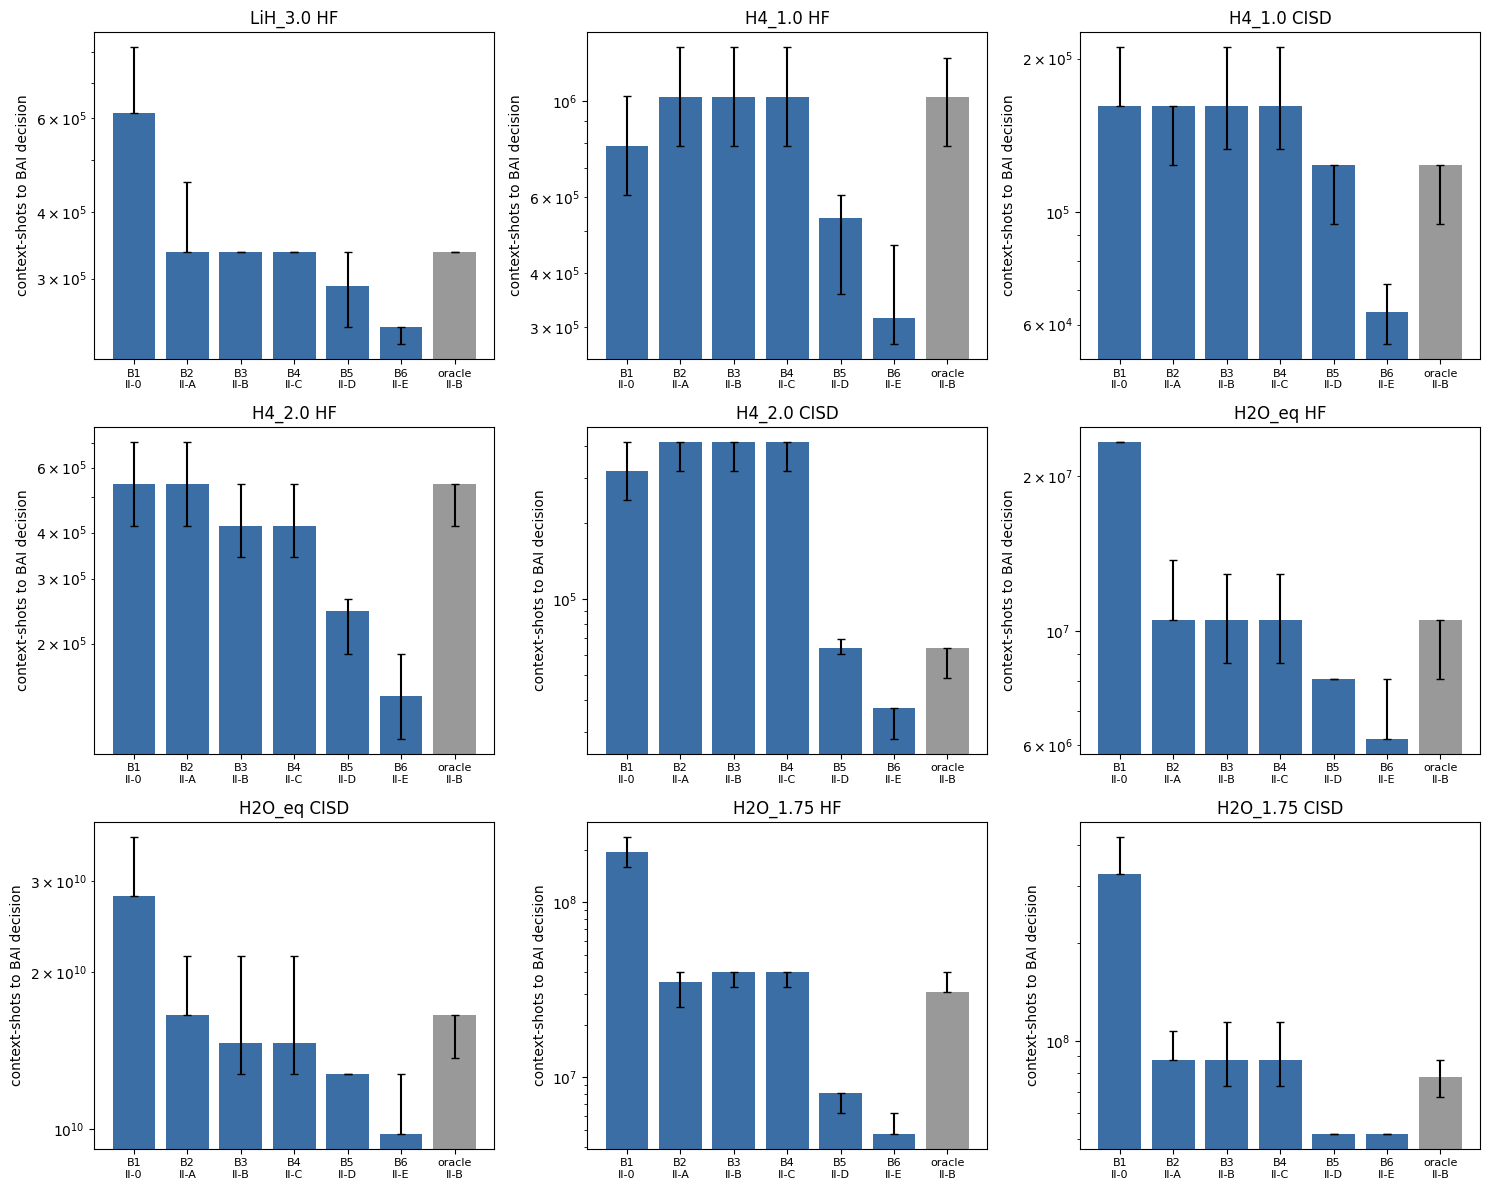

In [27]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=False)
meths = list(METHODS)
for ax, (sysname, st) in zip(axes.ravel(), [(a, b) for a in STATES for b in STATES[a]]):
    sub = summary[(summary.system == sysname) & (summary.state == st)].set_index("method").reindex(meths)
    y = sub.N50.values
    err = np.vstack([y - sub.N25.values, sub.N75.values - y])
    cols = ["#999999" if m.startswith("oracle") else "#3b6ea5" for m in meths]
    ax.bar(range(len(meths)), y, yerr=err, color=cols, capsize=3)
    ax.set_yscale("log")
    ax.set_xticks(range(len(meths)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in meths], fontsize=8)
    ax.set_title(f"{sysname} {st}")
    ax.set_ylabel("context-shots to BAI decision")
plt.tight_layout()
plt.savefig(f"{OUT}/fig_shots_by_method.png", dpi=130)
plt.show()

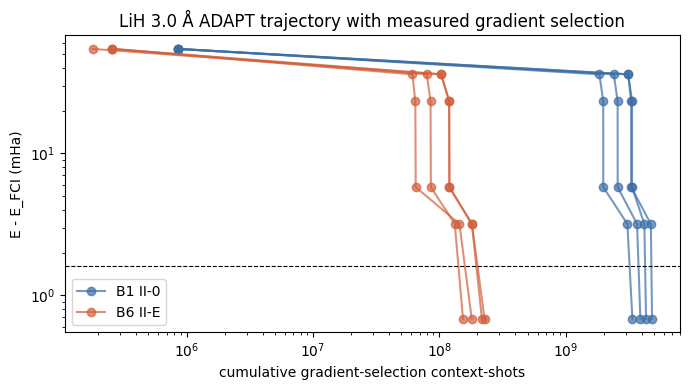

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
for (method, seed), grp in traj_df.groupby(["method", "seed"]):
    ax.plot(grp.cumulative_shots, grp.dE_mHa, marker="o", color="#3b6ea5" if method == "B1 II-0" else "#d1603d",
            alpha=0.7, label=method if seed == 0 else None)
ax.axhline(1.6, ls="--", color="k", lw=0.8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("cumulative gradient-selection context-shots"); ax.set_ylabel("E - E_FCI (mHa)")
ax.set_title("LiH 3.0 Å ADAPT trajectory with measured gradient selection")
ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/fig_adapt_trajectory.png", dpi=130); plt.show()

## 13. Results summary

All nine Part I rows, including the full 14-qubit H₂O. Δ = 1 mHa, δ = 0.05. Every run picked the exact best generator (1,400 benchmark runs and 180 extra ν-sweep runs).

### Median context-shots, change relative to II-0

| Row | II-0 | II-A | II-B | II-D | II-E | oracle II-B |
|---|---|---|---|---|---|---|
| LiH HF | 6.1e5 | −45% | −45% | −53% | −60% | −45% |
| H₄ 1.0 HF | 7.9e5 | +30% | +30% | −32% | −60% | +30% |
| H₄ 1.0 CISD | 1.6e5 | 0% | 0% | −23% | −61% | −23% |
| H₄ 2.0 HF | 5.4e5 | 0% | −23% | −55% | −73% | 0% |
| H₄ 2.0 CISD | 3.2e5 | +30% | +30% | −80% | −88% | −80% |
| H₂O eq HF | 2.3e7 | −55% | −55% | −65% | −74% | −55% |
| H₂O eq CISD | 2.8e10 | −41% | −48% | −54% | −65% | −41% |
| H₂O 1.75 HF | 1.9e8 | −82% | −79% | −96% | −98% | −84% |
| H₂O 1.75 CISD | 3.3e8 | −73% | −73% | −84% | −84% | −76% |

II-C removed no context in any system, so its rows equal II-B.

### What the table shows
1. **Direct contrasts (II-E) win everywhere.** They save 60–98%, and most where the two leading gradients are close.
2. **Splitting (II-A) depends on the molecule.** It saves 41–82% on LiH and H₂O. On H₄ it saves nothing or costs 30% more, because it lowers the total variance but not the variance of the deciding contrast.
3. **Measured covariances (II-D) save in every row**, including the H₄ CISD rows where the HF prior misleads the fixed designs.
4. **Knowing the covariance exactly is not enough.** The oracle average-variance design never beats the non-oracle II-E.

### Link to Part I
Part II's II-0 is the finite-shot counterpart of Part I's M3. It costs 1.1–17 times the oracle M3 estimate, because it keeps one static allocation. II-E uses no oracle information and still needs only 39–89% of the oracle M3 on six rows (LiH, H₄ 1.0 HF and all four H₂O rows). On the other three H₄ rows it needs 1.02–1.41 times M3.

### Extra analyses
- **Prior transfer.** The HF-prior design is near exact for H₂O but no better than II-0 for H₄ (1.31× the variance at 2.0 Å). Designs learned from data are 2–2.4× worse than II-0 at about 5 shots per context, and within 5% of exact at about 400.
- **ν sensitivity.** For H₄, ν = 0 costs 2.2–3.0× more and ν = ∞ costs 1.1–3.4× more; ν = 20–1000 is safe. H₂O 1.75 CISD does not depend on ν.

### Phases 3 and 4
- **Phase 3:** II-E picked the correct LiH generator in 6.1e5 context-shots.
- **Phase 4:** II-E reached chemical accuracy on LiH with 2.0e8 selection shots, against 4.1e9 for II-0.